# Same loss, different algorithm: two sorting transformers and the geometry that separates them

*A self-contained toy experiment on the "underspecification" argument from singular learning theory.
Everything runs in one notebook; the committed outputs were produced on a rented Hugging Face T4 GPU
(about 30 minutes).*

**Summary.**  One tiny transformer architecture, one training objective (sort strings of 4–10 digits),
two weight vectors that both reach 100% accuracy at a loss of ~1e-7 nats per token or less.  One
implements a *pointer-tracking* algorithm (keep the last emitted value, emit the smallest input digit that is
still available), the other a *counting sort* (compute cumulative counts once, emit digit `d` at output
indices `C(d-1) … C(d)-1`).  They were produced by supervising an explicit 11-number state bottleneck in
the same architecture.  Nothing about the training distribution distinguishes them; on longer inputs the
pointer-tracker keeps sorting (100% at n = 16, 87% at n = 24) while the counting sorter collapses within a few
positions of the training range (3% at n = 16).  Three independent tests — corrupted-prefix behaviour,
what each bottleneck holds, attention patterns — confirm that the two networks compute different things,
and a third model trained with no state supervision turns out to be a pointer-tracker: SGD's default.
Finally we estimate the local learning coefficient (LLC) of each solution with SGLD, for three seeds per
model and two sampler settings.  SGD's own solution is 20–70× more degenerate than either scaffolded one.
Between the two equal-loss solutions, geometry separates them by a factor of two at the setting that
probes the sharpest directions (consistently across seeds; the weight-refined LLC puts the pointer-tracker's
stiffness in its attention look-ups and the counting sorter's in its read-out thresholds) — with the
brittle counting sorter as the *more* degenerate one — and does not separate them at a colder setting.

## 1. Background: why "same loss, different algorithm" matters for safety

This notebook is a toy instantiation of an argument that runs through three pieces of recent
writing on **singular learning theory (SLT)** and alignment:

* Jesse Hoogland, *[Singular Learning Theory for AI Safety](https://www.jessehoogland.com/article/lesswrong/2025-07-01-slt-for-ai-safety)* (2025).
  Alignment today is mostly *data engineering*: the same optimiser and architecture are pointed at a
  curated distribution and we hope the right algorithm falls out.  Two things can go wrong.  The
  **learning problem**: training can converge to a solution that matches the training specification
  but is not the one we intended.  The **generalisation problem**: the intended and unintended
  solutions agree on the training distribution and only come apart under distribution shift, when
  "capabilities generalise further than alignment".  SLT's proposal is that the *geometry of the loss
  landscape around a solution reflects the algorithm it implements* (the "S4" chain: statistical
  structure in data → geometric structure of the loss → developmental structure → algorithmic
  structure in the weights), so that measuring geometry can tell solutions apart even when their
  loss cannot.
* The LessWrong [Singular Learning Theory wiki page](https://www.lesswrong.com/w/singular-learning-theory)
  and the "Distilling SLT" sequence: neural networks are *singular* models — many weight
  configurations implement the same function, and the set of low-loss weights is not a nice
  manifold but a variety with degenerate directions.  Watanabe's theory replaces the parameter count
  by the **learning coefficient** λ (the real log canonical threshold): the Bayesian free energy of a
  region around a minimum w* behaves as  F_n ≈ n L_n(w*) + λ(w*) log n,  so among solutions with equal
  loss the posterior overwhelmingly prefers the *more degenerate* one (smaller λ = "simpler").
* Lehalleur, Hoogland, Farrugia-Roberts, Wei, Gietelink Oldenziel, Wang, Carroll & Murfet,
  *[You Are What You Eat — AI alignment requires understanding how data shapes structure and generalisation](https://arxiv.org/abs/2502.05475)* (2025).
  Its Section 3 is the **underspecification problem**: many parameter configurations reach the same
  training loss but generalise differently outside the training distribution, so evaluations on the
  training distribution cannot certify safety.  Their Eq. (3) writes the posterior log-odds between two
  such solutions 𝒰 and 𝒱 as

  $$\log \frac{p_n(\mathcal U)}{p_n(\mathcal V)} = n\,\Delta\ell_n + \Delta\lambda\,\log n + O_p(\log\log n),$$

  where Δℓ is the difference in training loss and Δλ the difference in **local learning coefficient
  (LLC)**.  When Δℓ ≈ 0 the geometry term decides, and the paper's worry is that the simpler (lower-λ)
  solution may be the *misaligned* shortcut.

The LLC of a trained network can be estimated (Lau, Furman, Wang, Murfet & Wei, 2023,
*[The Local Learning Coefficient: a singularity-aware complexity measure](https://arxiv.org/abs/2308.12108)*)
by sampling the tempered, localised posterior with stochastic-gradient Langevin dynamics:

$$\hat\lambda(w^*) = n\beta^*\Big(\mathbb E_{w\,\sim\,p(w\mid w^*,\beta^*,\gamma)}[L_n(w)] - L_n(w^*)\Big),\qquad
\Delta w = \tfrac{\epsilon}{2}\Big(-n\beta^*\nabla L_{\text{batch}}(w) + \gamma\,(w^*-w)\Big) + \mathcal N(0,\epsilon),$$

with β* = 1/log n, localisation γ and step size ε (this is what the `devinterp` library implements;
we re-implement the ~30 lines below so that the notebook has no dependencies beyond PyTorch).

**What the toy is meant to show.**  Take one architecture and one training objective, and produce two
weight vectors with the *same* training loss that implement *different algorithms*.  Then check that
(i) the difference is invisible in-distribution, (ii) it becomes visible under a distribution shift
(longer inputs) — the "alignment/misalignment boundary" — and (iii) whether the LLC, a purely
geometric quantity computed on the *training* distribution, can tell the two apart.

## 2. The toy: two sorting algorithms in one transformer

**Task.**  Sort a string of `n` digits.  The model sees `x_1 … x_n  |  y_1 … y_n` where `y = sorted(x)`,
and is trained (teacher-forced, cross-entropy) to predict `y_t` from everything before it.  Input
digits and output digits use *different* token ids, so the model can tell them apart by content
alone.  Training lengths are `n ∈ {4, …, 10}`; digits are i.i.d. uniform, so duplicates are common.
There is no train/test split in the usual sense — every batch is freshly sampled — so "training loss"
is population loss on the training distribution.

**Two algorithms that both solve the task.**

| | PNTR — "a pointer to the current minimum" | HIST — "counting sort" |
|---|---|---|
| state at output step *t* | which digits are *still available* (10 bits) and the current value `v = y_{t-1}` | the histogram of absolute counts of the 10 digits, and the output index `t` |
| decision | emit the smallest available digit ≥ `v` | emit the digit `d` with `C(d-1) ≤ t < C(d)`, `C` = cumulative counts |
| what it depends on | the *previous outputs* (sequential) | the *position index* and *absolute counts* (parallel, ignores previous outputs) |
| scale | only comparisons ("is d still available?", "is d ≥ v?") — nothing depends on `n` | absolute magnitudes (counts, index) whose range is bounded by the training lengths |

Both are 100% correct on the training distribution, so the sorting loss cannot distinguish them.
They differ in *what else they do*: the pointer-tracker keeps working for longer inputs, the counting
sorter has never seen a count above ~5 or an index above 9 and has no reason to handle them.

**Architecture (identical for every model).**  A 2-layer, 4-head, d=128 GPT-style decoder with **no
position embeddings** (causal attention plus separate input/output vocabularies is enough for both
algorithms, and it means that the only thing that changes out of distribution is the number of tokens —
there are no untrained position parameters to blame; learned position embeddings are an ablation).
The transformer body ends in an explicit **11-dimensional state vector** `s = W·LN(resid)`, and the
sorting decision is a small MLP read-out of `s` alone.  This bottleneck is what makes the "supervised
state" *binding*: the model can only sort through those 11 numbers.  (Without it — ablation B at the
end — the auxiliary supervision is satisfied but ignored: SGD represents the histogram and still sorts by
tracking the minimum.)

**Supervised-state training.**  The three models differ *only* in what `s` is asked to be:

* `PNTR`  : `s = [ availability bits (10) | v ]`  (v = the last emitted digit, −1 at the separator),
* `HIST` : `s = [ cumulative counts C(0..9) (10) | t ]`  (C(d) = number of inputs ≤ d, t = output index),
* `NONE` : nothing — whatever SGD finds on its own.

Training has two phases.  In the *state phase* (80% of the steps) the body is trained only to produce
the state (MSE), and the read-out is trained only on the sorting loss while reading the *true* state
(plus a little noise) — teacher forcing of the state, so that nothing but the intended 11 numbers can
flow from body to decision.  In the *joint phase* (the last 20%, small learning rate) everything is
fine-tuned end-to-end on the pure sorting loss, so that the weights we compare are minima of the same
objective.  (Naive joint training of body, read-out and auxiliary loss does not work: the read-out
learns to decode the previous output from tiny deviations of the state — a pilot result that motivated
the two-phase scheme.)

**Measurements.**  (1) training loss / in-distribution accuracy; (2) free-running accuracy for lengths
`n = 4 … 32`; (3) accuracy at `n = 10` with many duplicates (small alphabets: counts far above the
training range while positions stay in range); (4) mechanistic tests — does the next prediction follow a
*corrupted* previous output (pointer-tracker) or ignore it (counting sort)?  which algorithm's state is
linearly decodable?  what do the attention heads attend to?; (5) the local learning coefficient of each
solution, estimated with SGLD on a fixed sample from the training distribution with identical sampler
settings for every model.

## Code

Everything below is self-contained (also available as `slt_sorting_lib.py` in the repo).

In [ ]:
import math, time, copy, json, os, random
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# ----------------------------------------------------------------------------------------
# Tokens.  Input digits and output digits use *different* token ids so that the model can
# tell them apart by content alone (no positional information needed for that).
# ----------------------------------------------------------------------------------------
N_DIGITS = 10
SEP = 10                # separator token
OUT0 = 11               # output digit d  ->  token id OUT0 + d
VOCAB = OUT0 + N_DIGITS # 21

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [ ]:
# ----------------------------------------------------------------------------------------
# Data
# ----------------------------------------------------------------------------------------
def sample_inputs(B: int, n: int, alphabet: int = N_DIGITS, device=DEVICE, generator=None):
    """B random digit strings of length n, digits i.i.d. uniform on {0..alphabet-1}."""
    return torch.randint(0, alphabet, (B, n), device=device, generator=generator)


def build_tokens(x: torch.Tensor):
    """[x_1..x_n, SEP, y_1..y_n] with y = sorted(x).  Shape (B, 2n+1)."""
    B, n = x.shape
    y = x.sort(dim=1).values
    sep = torch.full((B, 1), SEP, dtype=torch.long, device=x.device)
    return torch.cat([x, sep, y + OUT0], dim=1)


def histogram(x: torch.Tensor):
    """Absolute counts of each digit, (B, 10) float."""
    return F.one_hot(x, N_DIGITS).sum(1).float()


def availability(x: torch.Tensor, y: torch.Tensor):
    """availability[b, t, d] = (count of d in x_b) > (count of d among y_b[:t]).
    This is the state of the PNTR algorithm at output step t (0-indexed): which digits are
    still left to emit.  y_t == min{d : availability[t, d]} always holds."""
    h = F.one_hot(x, N_DIGITS).sum(1)                       # (B, 10)
    yo = F.one_hot(y, N_DIGITS)                             # (B, n, 10)
    out_before = torch.cumsum(yo, dim=1) - yo               # counts of y[:, :t] (exclusive)
    return (h[:, None, :] - out_before) > 0                 # (B, n, 10) bool


def counting_sort_state(x: torch.Tensor):
    """State of the HIST algorithm: the histogram (same at every output step) and the output
    index t.  Returns (hist (B,10), t (n,))."""
    B, n = x.shape
    return histogram(x), torch.arange(n, device=x.device, dtype=torch.float)


def state_targets(x: torch.Tensor, y: torch.Tensor, mode: str):
    """The 11-dim supervised state at each of the n decision points, (B, n, 11), or None.
      PNTR : [availability bits (10) | v]  with v = previously emitted digit (-1 at the separator)
      HIST: [cumulative counts C(d) (10) | t] with C(d) = #inputs <= d, t = 0-indexed output index
    Both states carry 10 per-digit numbers plus one 'where am I' number: in *value* space for the
    pointer-tracker (the current minimum v), in *index* space for counting sort (the output index t)."""
    B, n = x.shape
    if mode == "pntr":
        a = availability(x, y).float()
        v = torch.cat([torch.full((B, 1), -1.0, device=x.device), y[:, :-1].float()], 1)
        return torch.cat([a, v[:, :, None]], -1)
    if mode == "hist":
        h, t = counting_sort_state(x)
        C = torch.cumsum(h, 1)                                   # C[d] = #inputs <= d  (C[9] = n)
        return torch.cat([C[:, None, :].expand(B, n, N_DIGITS), t[None, :, None].expand(B, n, 1)], -1)
    return None

In [ ]:
# ----------------------------------------------------------------------------------------
# Model: a tiny GPT-style decoder with (optional) learned absolute positional embeddings,
# a 10-way sorting head, and three *auxiliary linear probe heads* that read the residual
# stream after `probe_layer` blocks.  The probe heads are only used during training.
# ----------------------------------------------------------------------------------------
@dataclass
class Config:
    d_model: int = 128
    n_heads: int = 4
    n_layers: int = 2
    d_mlp: int = 512
    max_len: int = 96        # supports input length n <= 47
    pos: str = "learned"     # 'learned' (zero-init absolute) | 'none' (NoPE) | 'sinusoidal'
    probe_layer: int = 1     # residual stream after this many blocks feeds the (non-bottleneck) probes
    bottleneck: bool = True  # route the sorting decision through an explicit K-dim "state" vector
    state_dim: int = 11      # 10 per-digit slots + 1 "where am I" slot (v for PNTR, t for HIST)
    readout_hidden: int = 64


class Attention(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        assert d % h == 0
        self.h, self.dh = h, d // h
        self.qkv = nn.Linear(d, 3 * d)
        self.out = nn.Linear(d, d)

    def forward(self, x, return_attn=False):
        B, T, D = x.shape
        q, k, v = self.qkv(x).view(B, T, 3, self.h, self.dh).unbind(2)
        q, k, v = (z.transpose(1, 2) for z in (q, k, v))          # (B, h, T, dh)
        s = (q @ k.transpose(-1, -2)) / math.sqrt(self.dh)         # (B, h, T, T)
        mask = torch.ones(T, T, dtype=torch.bool, device=x.device).tril()
        s = s.masked_fill(~mask, float("-inf"))
        a = s.softmax(-1)
        y = (a @ v).transpose(1, 2).reshape(B, T, D)
        return self.out(y), (a if return_attn else None)


class Block(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = Attention(cfg.d_model, cfg.n_heads)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.mlp = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_mlp), nn.GELU(),
                                 nn.Linear(cfg.d_mlp, cfg.d_model))

    def forward(self, x, return_attn=False):
        a, attn = self.attn(self.ln1(x), return_attn)
        x = x + a
        x = x + self.mlp(self.ln2(x))
        return x, attn


def sinusoidal_table(max_len, d):
    pos = torch.arange(max_len, dtype=torch.float)[:, None]
    i = torch.arange(0, d, 2, dtype=torch.float)
    ang = pos / (10000 ** (i / d))
    pe = torch.zeros(max_len, d)
    pe[:, 0::2] = ang.sin(); pe[:, 1::2] = ang.cos()
    return pe


class SortingTransformer(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(VOCAB, cfg.d_model)
        if cfg.pos == "learned":
            # zero-initialised: positions that are never seen in training stay *exactly* zero,
            # i.e. an unseen position contributes no signal at all (rather than random noise).
            self.pos_emb = nn.Parameter(torch.zeros(cfg.max_len, cfg.d_model))
        elif cfg.pos == "sinusoidal":
            self.register_buffer("pos_table", sinusoidal_table(cfg.max_len, cfg.d_model))
            self.pos_emb = None
        else:
            self.pos_emb = None
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        if cfg.bottleneck:
            # residual -> K-dim state -> small MLP readout -> 10 logits.  The *only* path from the
            # transformer body to the sorting decision goes through the K numbers in `state`.
            self.state = nn.Linear(cfg.d_model, cfg.state_dim)
            self.readout = nn.Sequential(nn.Linear(cfg.state_dim, cfg.readout_hidden), nn.GELU(),
                                         nn.Linear(cfg.readout_hidden, cfg.readout_hidden), nn.GELU(),
                                         nn.Linear(cfg.readout_hidden, N_DIGITS))
        else:
            self.head = nn.Linear(cfg.d_model, N_DIGITS)
        # auxiliary probe heads (training-time scaffolding for the non-bottleneck variant only)
        self.probe_hist = nn.Linear(cfg.d_model, N_DIGITS)   # absolute counts / 10
        self.probe_idx = nn.Linear(cfg.d_model, 1)           # output index t / 10
        self.probe_avail = nn.Linear(cfg.d_model, N_DIGITS)  # availability bits (logits)

    def main_params(self):
        """Parameters of the sorting model proper (probe heads excluded)."""
        return [p for name, p in self.named_parameters() if not name.startswith("probe_")]

    def forward(self, tokens, return_attn=False):
        B, T = tokens.shape
        x = self.tok_emb(tokens)
        if self.cfg.pos == "learned":
            x = x + self.pos_emb[:T][None]
        elif self.cfg.pos == "sinusoidal":
            x = x + self.pos_table[:T][None]
        attns, resid_probe = [], None
        for i, blk in enumerate(self.blocks):
            x, a = blk(x, return_attn)
            attns.append(a)
            if i + 1 == self.cfg.probe_layer:
                resid_probe = x
        if resid_probe is None:
            resid_probe = x
        xf = self.ln_f(x)
        if self.cfg.bottleneck:
            state = self.state(xf)
            logits = self.readout(state)
        else:
            state = None
            logits = self.head(xf)
        return {"logits": logits, "resid": resid_probe, "final": x, "state": state, "attn": attns}


def n_params(model):
    return sum(p.numel() for p in model.main_params())

In [ ]:
# ----------------------------------------------------------------------------------------
# Losses.  Predictions for y_0..y_{n-1} are read at positions n..2n-1 (SEP, y_0, .., y_{n-2}).
# ----------------------------------------------------------------------------------------
def forward_sort(model, x, return_attn=False):
    B, n = x.shape
    toks = build_tokens(x)
    out = model(toks[:, :2 * n], return_attn=return_attn)
    y = toks[:, n + 1:] - OUT0
    return out, y


def compute_losses(model, x, mode: str, aux_weight: float = 1.0):
    """mode in {'pntr', 'hist', 'none'}.  Returns (total, dict of scalars)."""
    B, n = x.shape
    out, y = forward_sort(model, x)
    logits = out["logits"][:, n:, :]                       # (B, n, 10)
    ce = F.cross_entropy(logits.reshape(-1, N_DIGITS), y.reshape(-1))
    acc = (logits.argmax(-1) == y).float().mean()
    resid = out["resid"][:, n:, :]                         # (B, n, d) at the n decision points
    stats = {"ce": ce.item(), "acc": acc.item()}
    aux = torch.zeros((), device=x.device)
    if model.cfg.bottleneck:
        tgt = state_targets(x, y, mode)
        if tgt is not None:
            state = out["state"][:, n:, :]
            aux = F.mse_loss(state, tgt)
            stats["aux_state_mse"] = aux.item()
            if mode == "pntr":
                stats["avail_bit_acc"] = ((state[..., :10] > 0.5) == (tgt[..., :10] > 0.5)).float().mean().item()
            else:
                stats["count_acc"] = (state[..., :10].round() == tgt[..., :10]).float().mean().item()
    elif mode == "hist":
        h, t = counting_sort_state(x)
        ph = model.probe_hist(resid)                       # (B, n, 10)
        pt = model.probe_idx(resid).squeeze(-1)            # (B, n)
        l_h = F.mse_loss(ph, (h / 10.0)[:, None, :].expand_as(ph))
        l_t = F.mse_loss(pt, (t / 10.0)[None, :].expand_as(pt))
        aux = l_h + l_t
        stats.update({"aux_hist": l_h.item(), "aux_idx": l_t.item()})
    elif mode == "pntr":
        a = availability(x, y).float()
        pa = model.probe_avail(resid)
        l_a = F.binary_cross_entropy_with_logits(pa, a)
        aux = l_a
        stats.update({"aux_avail": l_a.item(), "avail_bit_acc": ((pa > 0) == (a > 0.5)).float().mean().item()})
    total = ce + aux_weight * aux
    stats["aux"] = aux.item(); stats["total"] = total.item()
    return total, stats

In [ ]:
# ----------------------------------------------------------------------------------------
# Training
# ----------------------------------------------------------------------------------------
def train_model(mode, cfg: Config, steps=8000, state_frac=0.7, batch=256, lr=1e-3, lr_joint=3e-4,
                wd=0.01, n_range=(4, 10), state_noise=0.1, readout_lr_mult=3.0, warmup=200, seed=0,
                log_every=250, device=DEVICE, verbose=True):
    """Supervised-state training in two phases.

    Phase 1 ("state phase", the first `state_frac` of the steps; skipped for mode 'none'):
      * the transformer body + state head are trained ONLY to output the algorithm's state
        (MSE to `state_targets`), they never see the sorting loss;
      * the read-out MLP is trained ONLY on the sorting loss, and reads the *true* state
        (plus a little Gaussian noise so that it learns margins) -- teacher forcing of the state.
      The state is therefore a hard, supervised interface: nothing else can flow through it.
    Phase 2 ("joint phase"): everything is fine-tuned end-to-end on the pure sorting loss with a
      smaller learning rate, so that the final weights are a minimum of the objective we compare.
    The log records, at every step, the sorting loss of the *composed* model (body -> state -> read-out),
    which is what is evaluated afterwards."""
    set_seed(seed)
    model = SortingTransformer(cfg).to(device)
    assert cfg.bottleneck, "supervised-state training needs the state bottleneck"
    S1 = int(steps * state_frac) if mode != "none" else 0
    S2 = steps - S1
    log, t0 = [], time.time()

    def cosine(s, S, base):
        if s < warmup:
            return base * (s + 1) / warmup
        p = (s - warmup) / max(1, S - warmup)
        return base * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * p)))

    # ---------------- phase 1: state phase ----------------
    ro_params = list(model.readout.parameters()); ro_ids = {id(p) for p in ro_params}
    body_params = [p for p in model.parameters() if id(p) not in ro_ids]
    opt = torch.optim.AdamW([{"params": body_params, "mult": 1.0}, {"params": ro_params, "mult": readout_lr_mult}],
                            lr=lr, weight_decay=wd, betas=(0.9, 0.98))
    for s in range(S1):
        for g in opt.param_groups:
            g["lr"] = cosine(s, S1, lr) * g["mult"]
        n = random.randint(*n_range)
        x = sample_inputs(batch, n, device=device)
        out, y = forward_sort(model, x)
        tgt = state_targets(x, y, mode)                              # (B, n, K)
        state = out["state"][:, n:, :]
        l_state = F.mse_loss(state, tgt)                             # body + state head
        logits_tf = model.readout(tgt + state_noise * torch.randn_like(tgt))
        l_read = F.cross_entropy(logits_tf.reshape(-1, N_DIGITS), y.reshape(-1))   # read-out only
        loss = l_state + l_read
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if s % log_every == 0 or s == S1 - 1:
            with torch.no_grad():
                logits = out["logits"][:, n:, :]
                ce = F.cross_entropy(logits.reshape(-1, N_DIGITS), y.reshape(-1)).item()
                acc = (logits.argmax(-1) == y).float().mean().item()
                read_acc = (logits_tf.argmax(-1) == y).float().mean().item()
            rec = {"phase": 1, "step": s, "n": n, "ce": ce, "acc": acc, "state_mse": l_state.item(),
                   "readout_ce": l_read.item(), "readout_acc": read_acc, "lr": cosine(s, S1, lr), "time": time.time() - t0}
            log.append(rec)
            if verbose:
                print(f"[{mode:4s} P1] step {s:5d} n={n:2d} composed ce={ce:.4f} acc={acc:.4f} | state mse={l_state.item():.5f} | read-out(true state) ce={l_read.item():.4f} acc={read_acc:.4f} ({rec['time']:.0f}s)")

    # ---------------- phase 2: joint fine-tuning on the pure sorting loss ----------------
    base = lr if mode == "none" else lr_joint
    opt = torch.optim.AdamW(model.parameters(), lr=base, weight_decay=wd, betas=(0.9, 0.98))
    for s in range(S2):
        for g in opt.param_groups:
            g["lr"] = cosine(s, S2, base)
        n = random.randint(*n_range)
        x = sample_inputs(batch, n, device=device)
        out, y = forward_sort(model, x)
        logits = out["logits"][:, n:, :]
        loss = F.cross_entropy(logits.reshape(-1, N_DIGITS), y.reshape(-1))
        acc = (logits.argmax(-1) == y).float().mean().item()
        rec = {"phase": 2, "step": S1 + s, "n": n, "ce": loss.item(), "acc": acc, "lr": cosine(s, S2, base), "time": time.time() - t0}
        if mode != "none":
            with torch.no_grad():
                rec["state_mse"] = F.mse_loss(out["state"][:, n:, :], state_targets(x, y, mode)).item()
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if s % log_every == 0 or s == S2 - 1:
            log.append(rec)
            if verbose:
                sm = f" | state mse={rec['state_mse']:.5f}" if "state_mse" in rec else ""
                print(f"[{mode:4s} P2] step {S1 + s:5d} n={n:2d} ce={loss.item():.4f} acc={acc:.4f}{sm} ({rec['time']:.0f}s)")
    model.eval()
    return model, log


def train_model_joint(mode, cfg: Config, steps=6000, batch=256, lr=1e-3, wd=0.01, n_range=(4, 10),
                      aux_weight=1.0, aux_off_frac=0.8, warmup=200, seed=0, log_every=250, device=DEVICE,
                      verbose=True):
    """The naive version of supervised-state training, used only in the ablation: no bottleneck,
    the sorting loss and an auxiliary *probe* loss on the residual stream are minimised jointly
    (the probe loss is switched off for the last (1 - aux_off_frac) of the steps)."""
    set_seed(seed)
    model = SortingTransformer(cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=(0.9, 0.98))
    def lr_at(s):
        if s < warmup:
            return lr * (s + 1) / warmup
        p = (s - warmup) / max(1, steps - warmup)
        return lr * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * p)))
    log, t0 = [], time.time()
    for s in range(steps):
        for g in opt.param_groups:
            g["lr"] = lr_at(s)
        n = random.randint(*n_range)
        x = sample_inputs(batch, n, device=device)
        w = aux_weight if s < aux_off_frac * steps else 0.0
        loss, stats = compute_losses(model, x, mode, w)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if s % log_every == 0 or s == steps - 1:
            stats.update({"step": s, "n": n, "aux_weight": w, "time": time.time() - t0})
            log.append(stats)
            if verbose:
                print(f"[{mode:4s} joint] step {s:5d} n={n:2d} ce={stats['ce']:.4f} acc={stats['acc']:.4f} aux={stats['aux']:.4f} aux_w={w:.1f} ({stats['time']:.0f}s)")
    model.eval()
    return model, log

In [ ]:
# ----------------------------------------------------------------------------------------
# Evaluation
# ----------------------------------------------------------------------------------------
@torch.no_grad()
def generate(model, x):
    """Greedy autoregressive sorting: returns predicted sorted digits (B, n)."""
    B, n = x.shape
    seq = torch.cat([x, torch.full((B, 1), SEP, dtype=torch.long, device=x.device)], 1)
    for t in range(n):
        logits = model(seq)["logits"][:, -1]
        seq = torch.cat([seq, (logits.argmax(-1) + OUT0)[:, None]], 1)
    return seq[:, n + 1:] - OUT0


@torch.no_grad()
def evaluate(model, n, B=1024, alphabet=N_DIGITS, seed=1234, device=DEVICE):
    """Free-running exact-match accuracy, free-running token accuracy, teacher-forced token
    accuracy and teacher-forced mean CE for inputs of length n."""
    g = torch.Generator(device=device).manual_seed(seed)
    x = sample_inputs(B, n, alphabet=alphabet, device=device, generator=g)
    y = x.sort(1).values
    yhat = generate(model, x)
    exact = (yhat == y).all(1).float().mean().item()
    tok = (yhat == y).float().mean().item()
    out, _ = forward_sort(model, x)
    logits = out["logits"][:, n:, :]
    tf_acc = (logits.argmax(-1) == y).float().mean().item()
    ce = F.cross_entropy(logits.reshape(-1, N_DIGITS), y.reshape(-1)).item()
    return {"n": n, "exact": exact, "token": tok, "tf_token": tf_acc, "ce": ce}


def evaluate_lengths(model, ns, **kw):
    return [evaluate(model, n, **kw) for n in ns]


@torch.no_grad()
def train_loss_estimate(model, n_range=(4, 10), B=2048, seed=999, device=DEVICE):
    """Mean per-token CE and per-sequence NLL on the training distribution."""
    g = torch.Generator(device=device).manual_seed(seed)
    ces, nlls, accs = [], [], []
    for n in range(n_range[0], n_range[1] + 1):
        x = sample_inputs(B, n, device=device, generator=g)
        out, y = forward_sort(model, x)
        logits = out["logits"][:, n:, :]
        ce_tok = F.cross_entropy(logits.reshape(-1, N_DIGITS), y.reshape(-1), reduction="none").view(B, n)
        ces.append(ce_tok.mean().item()); nlls.append(ce_tok.sum(1).mean().item())
        accs.append((logits.argmax(-1) == y).all(1).float().mean().item())
    return {"ce_per_token": float(np.mean(ces)), "nll_per_sequence": float(np.mean(nlls)),
            "seq_acc_teacher_forced": float(np.mean(accs))}


@torch.no_grad()
def state_fidelity(model, n_range=(4, 10), B=1024, seed=321, device=DEVICE):
    """How well does the bottleneck state of a trained model match *each* algorithm's state?
    Returns per-slot errors for the PNTR and HIST targets (lower = closer)."""
    g = torch.Generator(device=device).manual_seed(seed)
    res = {}
    for mode in ["pntr", "hist"]:
        errs, bit_acc, cnt_acc = [], [], []
        for n in range(n_range[0], n_range[1] + 1):
            x = sample_inputs(B, n, device=device, generator=g)
            out, y = forward_sort(model, x)
            s = out["state"][:, n:, :]
            tgt = state_targets(x, y, mode)
            errs.append(F.mse_loss(s, tgt).item())
            if mode == "pntr":
                bit_acc.append(((s[..., :10] > 0.5) == (tgt[..., :10] > 0.5)).float().mean().item())
            else:
                cnt_acc.append((s[..., :10].round() == tgt[..., :10]).float().mean().item())
        res[f"mse_vs_{mode.upper()}_state"] = float(np.mean(errs))
        if mode == "pntr":
            res["avail_bit_acc"] = float(np.mean(bit_acc))
        else:
            res["count_acc"] = float(np.mean(cnt_acc))
    return res

In [ ]:
# ----------------------------------------------------------------------------------------
# Mechanistic test 1: does the model condition on the *previous outputs* (PNTR) or only on the
# input histogram and the output index (HIST)?  We teacher-force a corrupted prefix: the last
# emitted token y_{t-1} is replaced by a different digit v'.  A pointer-tracking model follows the
# corrupted value (it emits the smallest available digit >= v'); a counting-sort model ignores
# the prefix and still emits the true y_t.
# ----------------------------------------------------------------------------------------
@torch.no_grad()
def prefix_sensitivity(model, n=10, B=2048, seed=7, device=DEVICE):
    """Teacher-force a prefix whose last emitted digit y_{t-1} is replaced by v' and read the next
    prediction.  Reports the fraction of cases in which the model (a) emits what the PNTR algorithm
    would emit given the corrupted prefix, (b) emits the true y_t (what counting sort emits, since
    it never looks at the prefix), (c) anything else.  v' is chosen so that the two answers differ
    and so that some digit >= v' is still available (no fall-back ambiguity).  v' is always a digit that
    occurs in the input and is >= the digit before it, so the corrupted prefix is still a sorted,
    plausible-looking prefix -- it is just inconsistent with the input multiset."""
    g = torch.Generator(device=device).manual_seed(seed)
    x = sample_inputs(B, n, device=device, generator=g)
    y = x.sort(1).values
    t = torch.randint(1, n, (B,), device=device, generator=g)           # corrupt y_{t-1}, predict y_t
    true_next = y.gather(1, t[:, None]).squeeze(1)
    h = F.one_hot(x, N_DIGITS).sum(1)
    digits = torch.arange(N_DIGITS, device=device)
    # emitted counts of the uncorrupted prefix y_{<t-1}
    yo = F.one_hot(y, N_DIGITS)
    cum = torch.cumsum(yo, 1)                                            # cum[:, i] = counts of y[:, :i+1]
    before = torch.where((t - 2)[:, None] >= 0, cum[torch.arange(B), (t - 2).clamp(min=0)], torch.zeros_like(h))
    best_v, best_pred, found = torch.full((B,), -1, device=device), torch.full((B,), -1, device=device), torch.zeros(B, dtype=torch.bool, device=device)
    order = torch.randperm(N_DIGITS, generator=torch.Generator().manual_seed(seed)).to(device)
    for vp in order.tolist():                                            # random order over candidate v'
        vprime = torch.full((B,), vp, device=device)
        emitted = before + F.one_hot(vprime, N_DIGITS)
        avail = (h - emitted) > 0
        cand = avail & (digits[None] >= vp)
        prev = torch.where(t >= 2, y.gather(1, (t - 2).clamp(min=0)[:, None]).squeeze(1), torch.full_like(t, -1))
        ok = cand.any(1) & (vprime != y.gather(1, (t - 1)[:, None]).squeeze(1)) & (h[:, vp] > 0) & (vprime >= prev)
        pred = torch.where(cand, digits[None], torch.full_like(cand, 99, dtype=torch.long)).min(1).values
        ok = ok & (pred != true_next) & ~found
        best_v = torch.where(ok, vprime, best_v); best_pred = torch.where(ok, pred, best_pred); found |= ok
    keep = found
    x, y, t, true_next, best_v, best_pred = x[keep], y[keep], t[keep], true_next[keep], best_v[keep], best_pred[keep]
    ycor = y.clone(); ycor.scatter_(1, (t - 1)[:, None], best_v[:, None])
    toks = torch.cat([x, torch.full((x.shape[0], 1), SEP, dtype=torch.long, device=device), ycor + OUT0], 1)[:, :2 * n]
    pred = model(toks)["logits"][torch.arange(x.shape[0]), n + t].argmax(-1)
    m = x.shape[0]
    return {"follows_prefix(PNTR-like)": (pred == best_pred).float().mean().item(),
            "ignores_prefix(HIST-like)": (pred == true_next).float().mean().item(),
            "other": ((pred != best_pred) & (pred != true_next)).float().mean().item(), "n_cases": m}

In [ ]:
# ----------------------------------------------------------------------------------------
# Mechanistic test 2: post-hoc linear probes.  After training, freeze the model and fit
# *fresh* linear probes for both algorithm states on held-out data.  A state that the model
# actually computes should be linearly decodable from its residual stream.
# ----------------------------------------------------------------------------------------
@torch.no_grad()
def collect_features(model, n_range=(4, 10), B=512, seed=11, which="resid", device=DEVICE):
    g = torch.Generator(device=device).manual_seed(seed)
    feats, H, T, A = [], [], [], []
    for n in range(n_range[0], n_range[1] + 1):
        x = sample_inputs(B, n, device=device, generator=g)
        out, y = forward_sort(model, x)
        r = out[which][:, n:, :]                                           # (B, n, d) or (B, n, K)
        h, t = counting_sort_state(x)
        a = availability(x, y).float()
        feats.append(r.reshape(-1, r.shape[-1]))
        H.append((h[:, None, :].expand(B, n, N_DIGITS)).reshape(-1, N_DIGITS))
        T.append(t[None, :].expand(B, n).reshape(-1))
        A.append(a.reshape(-1, N_DIGITS))
    return torch.cat(feats), torch.cat(H), torch.cat(T), torch.cat(A)


def ridge_fit(X, Y, lam=1e-2):
    """Closed-form ridge regression with bias; returns predictor function."""
    Xb = torch.cat([X, torch.ones(X.shape[0], 1, device=X.device)], 1)
    d = Xb.shape[1]
    W = torch.linalg.solve(Xb.T @ Xb + lam * torch.eye(d, device=X.device), Xb.T @ Y)
    return lambda Z: torch.cat([Z, torch.ones(Z.shape[0], 1, device=Z.device)], 1) @ W


def r2(pred, Y):
    ss_res = ((pred - Y) ** 2).sum()
    ss_tot = ((Y - Y.mean(0)) ** 2).sum()
    return (1 - ss_res / ss_tot).item()


def logistic_fit(X, Y, steps=300, lr=0.05, wd=1e-4):
    """Multi-label linear logistic probe trained with Adam (full batch)."""
    lin = nn.Linear(X.shape[1], Y.shape[1]).to(X.device)
    opt = torch.optim.Adam(lin.parameters(), lr=lr, weight_decay=wd)
    for _ in range(steps):
        opt.zero_grad()
        F.binary_cross_entropy_with_logits(lin(X), Y).backward()
        opt.step()
    return lambda Z: lin(Z)


def probe_report(model, which="resid", device=DEVICE):
    """Fit probes on one seed's data, evaluate on another.  Returns R^2 for the histogram
    counts, R^2 for the index t, bit-accuracy for availability, and the accuracy of the
    *derived* sort prediction argmin{d: avail_d} from the availability probe."""
    Xtr, Htr, Ttr, Atr = collect_features(model, seed=11, which=which, device=device)
    Xte, Hte, Tte, Ate = collect_features(model, seed=12, which=which, device=device)
    mu, sd = Xtr.mean(0, keepdim=True), Xtr.std(0, keepdim=True) + 1e-6
    Xtr, Xte = (Xtr - mu) / sd, (Xte - mu) / sd
    fh = ridge_fit(Xtr, Htr); ft = ridge_fit(Xtr, Ttr[:, None])
    with torch.enable_grad():
        fa = logistic_fit(Xtr, Atr)
    with torch.no_grad():
        res = {"hist_R2": r2(fh(Xte), Hte),
               "hist_count_acc": (fh(Xte).round() == Hte).float().mean().item(),
               "idx_R2": r2(ft(Xte), Tte[:, None]),
               "avail_bit_acc": ((fa(Xte) > 0) == (Ate > 0.5)).float().mean().item()}
    return res

In [ ]:
# ----------------------------------------------------------------------------------------
# Local Learning Coefficient (Lau, Furman, Wang, Murfet, Wei 2023) via SGLD.
#   lambda_hat(w*) = n*beta * ( E_{w ~ tempered local posterior}[L_n(w)] - L_n(w*) )
#   SGLD:  dw = eps/2 * ( -n*beta * grad L_batch(w) + gamma * (w* - w) ) + N(0, eps)
# L_n is the mean *per-sequence* negative log-likelihood (sum over the n output tokens).
# ----------------------------------------------------------------------------------------
class FixedDataset:
    """A fixed i.i.d. sample of N sequences from the training distribution, grouped by n."""
    def __init__(self, N=16384, n_range=(4, 10), seed=2024, device=DEVICE):
        g = torch.Generator(device=device).manual_seed(seed)
        ns = list(range(n_range[0], n_range[1] + 1))
        per = N // len(ns)
        self.groups = {n: sample_inputs(per, n, device=device, generator=g) for n in ns}
        self.N = per * len(ns)
        self.device = device

    def sample(self, batch, generator=None):
        n = random.choice(list(self.groups))
        x = self.groups[n]
        idx = torch.randint(0, x.shape[0], (batch,), device=self.device, generator=generator)
        return x[idx]

    def full_loss(self, model, loss_fn, batch=2048):
        tot, cnt = 0.0, 0
        with torch.no_grad():
            for n, x in self.groups.items():
                for i in range(0, x.shape[0], batch):
                    xb = x[i:i + batch]
                    tot += loss_fn(model, xb).item() * xb.shape[0]; cnt += xb.shape[0]
        return tot / cnt


def sequence_nll(model, x):
    """Mean over the batch of the per-sequence NLL (summed over output tokens)."""
    B, n = x.shape
    out, y = forward_sort(model, x)
    logits = out["logits"][:, n:, :]
    ce = F.cross_entropy(logits.reshape(-1, N_DIGITS), y.reshape(-1), reduction="none").view(B, n)
    return ce.sum(1).mean()


def estimate_llc(model, data: FixedDataset, eps=1e-4, gamma=100.0, nbeta=None, n_chains=4,
                 n_steps=1000, burnin=400, batch=256, seed=0, loss_fn=sequence_nll, verbose=False,
                 param_filter=None):
    """SGLD-based LLC estimate.  Returns dict with per-chain estimates, the loss traces and the
    reference loss L_n(w*).  All chains start at w* and only the sorting model's parameters
    (not the probe heads) are sampled.  `param_filter(name) -> bool` restricts the sampled
    parameters to a subset (the *weight-refined* LLC of Wang et al. 2024); all other
    parameters stay frozen at w*."""
    if nbeta is None:
        nbeta = data.N / math.log(data.N)            # beta* = 1/log n  (Lau et al. 2023)
    device = data.device
    L0 = data.full_loss(model, loss_fn)
    names = [n for n, _ in model.named_parameters() if not n.startswith("probe_")]
    if param_filter is not None:
        names = [n for n in names if param_filter(n)]
    w_star = [p.detach().clone() for n, p in model.named_parameters() if n in set(names)]
    traces = np.zeros((n_chains, n_steps))
    chains_llc = []
    for c in range(n_chains):
        g = torch.Generator(device=device).manual_seed(seed * 1000 + c)
        torch.manual_seed(seed * 1000 + c)
        m = copy.deepcopy(model)
        name_set = set(names)
        params = [p for n, p in m.named_parameters() if n in name_set]
        for p, w0 in zip(params, w_star):
            p.data.copy_(w0)
        for s in range(n_steps):
            x = data.sample(batch, generator=g)
            loss = loss_fn(m, x)
            grads = torch.autograd.grad(loss, params)
            with torch.no_grad():
                for p, gr, w0 in zip(params, grads, w_star):
                    drift = -nbeta * gr + gamma * (w0 - p)
                    p.add_(0.5 * eps * drift + math.sqrt(eps) * torch.randn_like(p))
            traces[c, s] = loss.item()
        chain_est = nbeta * (traces[c, burnin:].mean() - L0)
        chains_llc.append(chain_est)
        if verbose:
            print(f"  chain {c}: L0={L0:.4f} mean(L)={traces[c, burnin:].mean():.4f} llc={chain_est:.2f}")
    chains_llc = np.array(chains_llc)
    return {"llc": float(chains_llc.mean()), "llc_std": float(chains_llc.std()),
            "per_chain": chains_llc.tolist(), "traces": traces, "L0": L0, "nbeta": nbeta,
            "eps": eps, "gamma": gamma, "burnin": burnin, "n_params": int(sum(w.numel() for w in w_star))}

In [ ]:
# ----------------------------------------------------------------------------------------
# Attention pattern helper (for visualisation)
# ----------------------------------------------------------------------------------------
@torch.no_grad()
def attention_patterns(model, x):
    """Returns list over layers of (B, heads, T, T) attention weights for tokens [x, SEP, y[:-1]]."""
    out, y = forward_sort(model, x, return_attn=True)
    return out["attn"], y


def token_labels(x_row):
    x_row = [int(v) for v in x_row]
    y_row = sorted(x_row)
    return [str(v) for v in x_row] + ["|"] + [f"{v}'" for v in y_row[:-1]]

## 3. Setup

Hyper-parameters.  `SLT_FAST=1` in the environment gives a ~5-minute CPU run with fewer steps and
SGLD chains (useful for checking the code); the numbers reported below come from the full run.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
os.makedirs("figures", exist_ok=True); os.makedirs("results", exist_ok=True)

FAST = os.environ.get("SLT_FAST", "0") == "1"      # SLT_FAST=1 gives a ~5-minute CPU run with fewer steps/chains
print("device:", DEVICE, "| torch", torch.__version__, "| fast mode:", FAST)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

CFG = Config(d_model=128, n_heads=4, n_layers=2, d_mlp=512, max_len=96, pos="none", probe_layer=1)
TRAIN = dict(steps=1500 if FAST else 6000, state_frac=0.8, batch=256, lr=1e-3, lr_joint=1e-4, wd=0.01,
             n_range=(4, 10), state_noise=0.1, seed=0, log_every=250)
OOD_LENGTHS = [4, 6, 8, 10, 11, 12, 13, 14, 16, 18, 20, 24, 28, 32]
MODES = {"PNTR": "pntr", "HIST": "hist", "NONE": "none"}   # NONE = no auxiliary state (what does SGD find on its own?)
print("model parameters:", n_params(SortingTransformer(CFG)))

device: cuda | torch 2.6.0+cu124 | fast mode: False
GPU: Tesla T4
model parameters: 406485


## 4. Train the three models

Same seed, same data stream, same architecture, same optimiser; the only difference is the auxiliary
state loss (`aux` in the log), which is switched off at 80% of training.

In [ ]:
models, logs = {}, {}
for name, mode in MODES.items():
    print(f"\n===== training {name} (aux state = {mode}) =====")
    models[name], logs[name] = train_model(mode, CFG, device=DEVICE, **TRAIN)


===== training PNTR (aux state = pntr) =====


[pntr P1] step     0 n=10 composed ce=2.3099 acc=0.1578 | state mse=2.79689 | read-out(true state) ce=2.3227 acc=0.0703 (2s)


[pntr P1] step   250 n= 6 composed ce=0.1396 acc=0.9382 | state mse=0.00592 | read-out(true state) ce=0.0093 acc=1.0000 (4s)


[pntr P1] step   500 n=10 composed ce=0.0636 acc=0.9793 | state mse=0.00365 | read-out(true state) ce=0.0005 acc=1.0000 (7s)


[pntr P1] step   750 n= 4 composed ce=0.0001 acc=1.0000 | state mse=0.00082 | read-out(true state) ce=0.0006 acc=1.0000 (9s)


...

[none P2] step  5000 n= 7 ce=0.0000 acc=1.0000 (43s)


[none P2] step  5250 n= 7 ce=0.0000 acc=1.0000 (46s)


[none P2] step  5500 n= 5 ce=0.0000 acc=1.0000 (48s)


[none P2] step  5750 n=10 ce=0.0000 acc=1.0000 (50s)


[none P2] step  5999 n= 8 ce=0.0000 acc=1.0000 (52s)


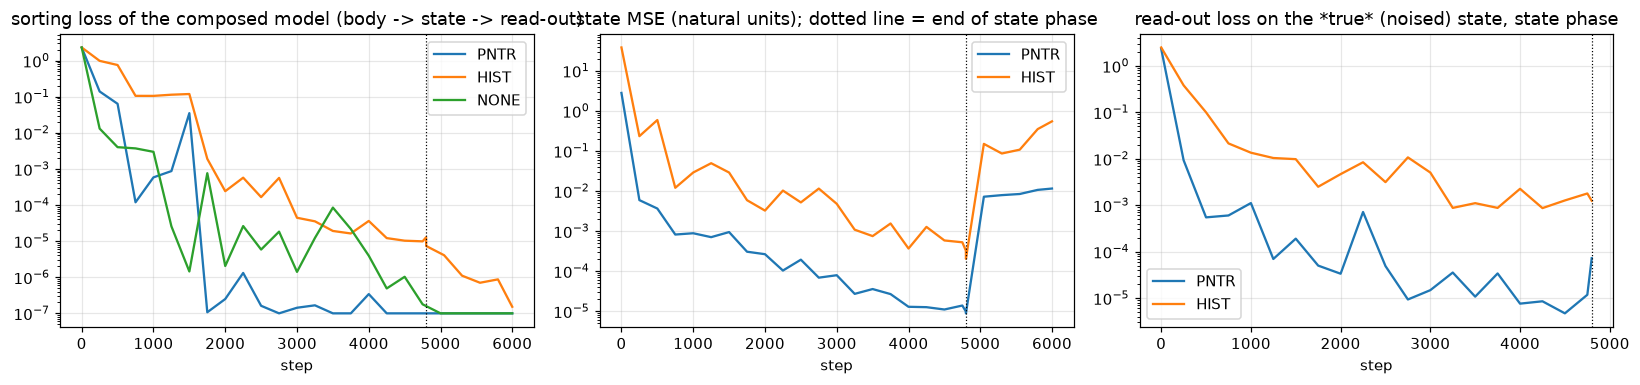

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for name, lg in logs.items():
    steps = [r["step"] for r in lg]
    axes[0].plot(steps, [max(r["ce"], 1e-7) for r in lg], label=name)
    st = [(r["step"], r["state_mse"]) for r in lg if "state_mse" in r]
    if st:
        axes[1].plot(*zip(*st), label=name)
    ro = [(r["step"], r["readout_ce"]) for r in lg if "readout_ce" in r]
    if ro:
        axes[2].plot(*zip(*ro), label=name)
S1 = int(TRAIN["steps"] * TRAIN["state_frac"])
for ax in axes:
    ax.axvline(S1, color="k", ls=":", lw=0.8)
axes[0].set_yscale("log"); axes[0].set_title("sorting loss of the composed model (body -> state -> read-out)"); axes[0].set_xlabel("step"); axes[0].legend()
axes[1].set_yscale("log"); axes[1].set_title("state MSE (natural units); dotted line = end of state phase"); axes[1].set_xlabel("step"); axes[1].legend()
axes[2].set_yscale("log"); axes[2].set_title("read-out loss on the *true* (noised) state, state phase"); axes[2].set_xlabel("step"); axes[2].legend()
plt.tight_layout(); plt.savefig("figures/training_curves.png"); plt.show()

In [ ]:
# Which state does each trained model actually hold in its bottleneck?  (MSE against each algorithm's
# state in natural units; bit accuracy of the availability slots; accuracy of the rounded count slots.)
fid = {name: state_fidelity(m, n_range=TRAIN["n_range"], device=DEVICE) for name, m in models.items()}
pd.DataFrame(fid).T

,mse_vs_PNTR_state,avail_bit_acc,mse_vs_HIST_state,count_acc
PNTR,0.012191,1.000000,16.692692,0.101993
HIST,22.121065,0.395376,0.424175,0.593899
NONE,26.849626,0.450107,46.316363,0.072219


## 5. The training objective cannot tell them apart

Population sorting loss on the training distribution (fresh samples, teacher forced) and the fraction
of sequences sorted perfectly.

In [ ]:
train_stats = {name: train_loss_estimate(m, n_range=TRAIN["n_range"], device=DEVICE) for name, m in models.items()}
df_train = pd.DataFrame(train_stats).T
df_train.columns = ["CE per token", "NLL per sequence", "exact-match acc (teacher forced)"]
df_train.to_csv("results/train_loss.csv")
df_train

,CE per token,NLL per sequence,exact-match acc (teacher forced)
PNTR,1.252774e-09,5.421599e-09,1.0
HIST,3.164539e-07,2.291304e-06,1.0
NONE,1.928145e-10,1.554976e-09,1.0


## 6. Distribution shift: longer inputs

Free-running (autoregressive, greedy) sorting accuracy as a function of the input length.  The
shaded band is the range of training lengths; everything to the right of it is out of distribution.

In [ ]:
ood = {name: evaluate_lengths(m, OOD_LENGTHS, B=1024, device=DEVICE) for name, m in models.items()}
rows = []
for name, rs in ood.items():
    for r in rs:
        rows.append({"model": name, **r})
df_ood = pd.DataFrame(rows); df_ood.to_csv("results/ood_lengths.csv", index=False)
piv = df_ood.pivot(index="n", columns="model", values="exact")
piv.columns = [f"{c}: exact-match acc" for c in piv.columns]
piv

,HIST: exact-match acc,NONE: exact-match acc,PNTR: exact-match acc
n,,,
4,1.000000,1.000000,1.000000
6,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000
10,1.000000,1.000000,1.000000
11,1.000000,1.000000,1.000000
12,0.999023,1.000000,1.000000
13,0.948242,1.000000,1.000000
14,0.702148,1.000000,1.000000
16,0.034180,0.997070,0.998047


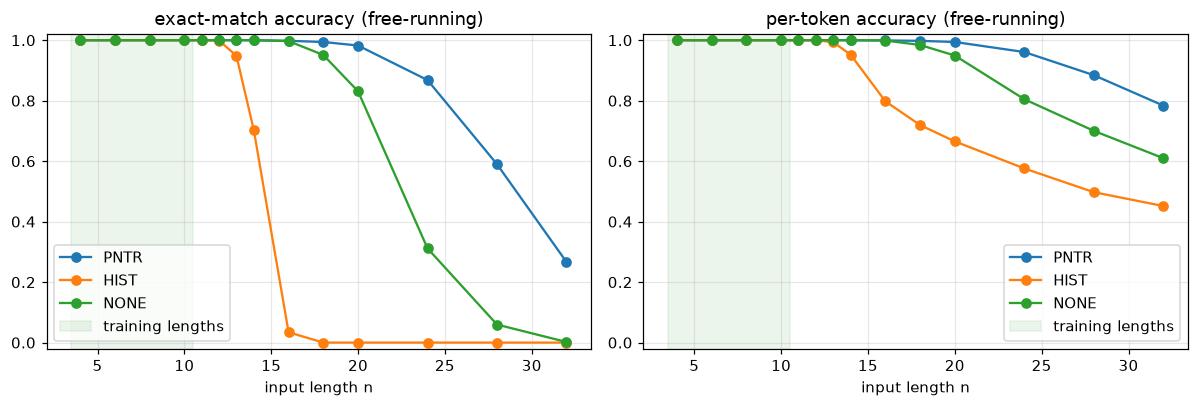

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, rs in ood.items():
    ns = [r["n"] for r in rs]
    axes[0].plot(ns, [r["exact"] for r in rs], "o-", label=name)
    axes[1].plot(ns, [r["token"] for r in rs], "o-", label=name)
for ax, t in zip(axes, ["exact-match accuracy (free-running)", "per-token accuracy (free-running)"]):
    ax.axvspan(TRAIN["n_range"][0] - 0.5, TRAIN["n_range"][1] + 0.5, color="green", alpha=0.08, label="training lengths")
    ax.set_xlabel("input length n"); ax.set_title(t); ax.set_ylim(-0.02, 1.02); ax.legend()
plt.tight_layout(); plt.savefig("figures/ood_length.png"); plt.show()

In [ ]:
# What does the failure look like?  Show a few OOD examples for each model.
g = torch.Generator(device=DEVICE).manual_seed(3)
x = sample_inputs(3, 16, device=DEVICE, generator=g)
for i in range(3):
    print("input :", " ".join(map(str, x[i].tolist())))
    print("sorted:", " ".join(map(str, x[i].sort().values.tolist())))
    for name, m in models.items():
        yhat = generate(m, x[i:i+1])[0].tolist()
        ok = yhat == x[i].sort().values.tolist()
        print(f"{name:5s}:", " ".join(map(str, yhat)), "" if ok else "  <-- wrong")
    print()

input : 1 9 1 9 1 1 7 6 2 2 3 4 3 6 0 4
sorted: 0 1 1 1 1 2 2 3 3 4 4 6 6 7 9 9
PNTR : 0 1 1 1 1 2 2 3 3 4 4 6 6 7 9 9 
HIST : 1 1 1 1 2 2 3 3 4 4 4 6 6 7 9 9   <-- wrong
NONE : 0 1 1 1 1 2 2 3 3 4 4 6 6 7 9 9 

input : 6 5 8 7 4 7 2 6 0 3 6 5 8 8 6 2
sorted: 0 2 2 3 4 5 5 6 6 6 6 7 7 8 8 8
PNTR : 0 2 2 3 4 5 5 6 6 6 6 7 7 8 8 8 
HIST : 2 2 3 4 5 5 5 6 6 6 6 7 7 8 8 8   <-- wrong
NONE : 0 2 2 3 4 5 5 6 6 6 6 7 7 8 8 8 

input : 2 5 9 1 8 2 7 5 6 3 2 9 6 8 0 5
sorted: 0 1 2 2 2 3 5 5 5 6 6 7 8 8 9 9
PNTR : 0 1 2 2 2 3 5 5 5 6 6 7 8 8 9 9 
HIST : 1 2 2 2 3 4 5 5 5 6 6 7 8 8 8 9   <-- wrong


NONE : 0 1 2 2 2 3 5 5 5 6 6 7 8 8 9 9 



## 7. Control: many duplicates at an in-distribution length

At `n = 10` nothing about the sequence length changes.  Drawing the digits from a smaller alphabet
makes the histogram unusual (with alphabet `{0}` one digit occurs 10 times, which never happens in
training), but the cumulative counts stay in their training range `0..10`.  This separates "the input
is longer" from "the counts are unusual".

In [ ]:
dup_rows = []
for name, m in models.items():
    for alpha in [10, 5, 3, 2, 1]:
        r = evaluate(m, 10, B=1024, alphabet=alpha, device=DEVICE)
        dup_rows.append({"model": name, "alphabet": f"{{0..{alpha-1}}}", "max count (typical)": "", **{k: r[k] for k in ["exact", "token"]}})
df_dup = pd.DataFrame(dup_rows).drop(columns=["max count (typical)"]); df_dup.to_csv("results/ood_duplicates.csv", index=False)
df_dup.pivot(index="alphabet", columns="model", values="exact")

model,HIST,NONE,PNTR
alphabet,,,
{0..0},0.000000,1.0,1.0
{0..1},0.990234,1.0,1.0
{0..2},0.999023,1.0,1.0
{0..4},1.000000,1.0,1.0
{0..9},1.000000,1.0,1.0


## 8. Are they really different algorithms?

**Prefix corruption.**  Teacher-force a prefix in which the *last emitted digit* `y_{t-1}` has been
replaced by a different digit `v'` — chosen so that the prefix is still sorted and `v'` occurs in the
input, i.e. the prefix looks perfectly plausible but is inconsistent with the input multiset — and look at
the model's next prediction.  A pointer-tracker follows the corrupted value (it emits the smallest
still-available digit ≥ `v'`); a counting sorter never looks at the prefix and emits the true `y_t`.
Only cases where the two answers differ are counted; "other" means the model emitted neither.

**Post-hoc linear probes.**  Fresh linear probes, fit on held-out data on the frozen residual stream
(after layer 1 and after layer 2), for both algorithms' states: R² for the absolute counts, R² for the
output index `t`, and bit accuracy for the availability bits.

**Attention patterns** at the ten decision points of one length-10 example.

In [ ]:
ps = {name: prefix_sensitivity(m, n=10, B=2048, device=DEVICE) for name, m in models.items()}
df_ps = pd.DataFrame(ps).T; df_ps.to_csv("results/prefix_sensitivity.csv")
df_ps

,follows_prefix(PNTR-like),ignores_prefix(HIST-like),other,n_cases
PNTR,0.994828,0.004598,0.000575,1740.0
HIST,0.012069,0.831034,0.156897,1740.0
NONE,0.720690,0.211494,0.067816,1740.0


In [ ]:
probe_rows = {}
for name, m in models.items():
    for which in ["resid", "final"]:
        probe_rows[(name, "after layer 1" if which == "resid" else "after layer 2")] = probe_report(m, which=which, device=DEVICE)
df_probe = pd.DataFrame(probe_rows).T; df_probe.to_csv("results/probes.csv")
df_probe

hist_R2  hist_count_acc    idx_R2  avail_bit_acc
PNTR after layer 1  0.711620        0.788783  0.838435       0.938975
     after layer 2  0.720082        0.792451  0.831982       1.000000
HIST after layer 1  0.986430        0.999171  0.996531       0.992941
     after layer 2  0.988191        0.999625  0.998556       0.993208
NONE after layer 1  0.885873        0.926698  0.929681       0.986655
     after layer 2  0.827609        0.868893  0.895079       0.956413

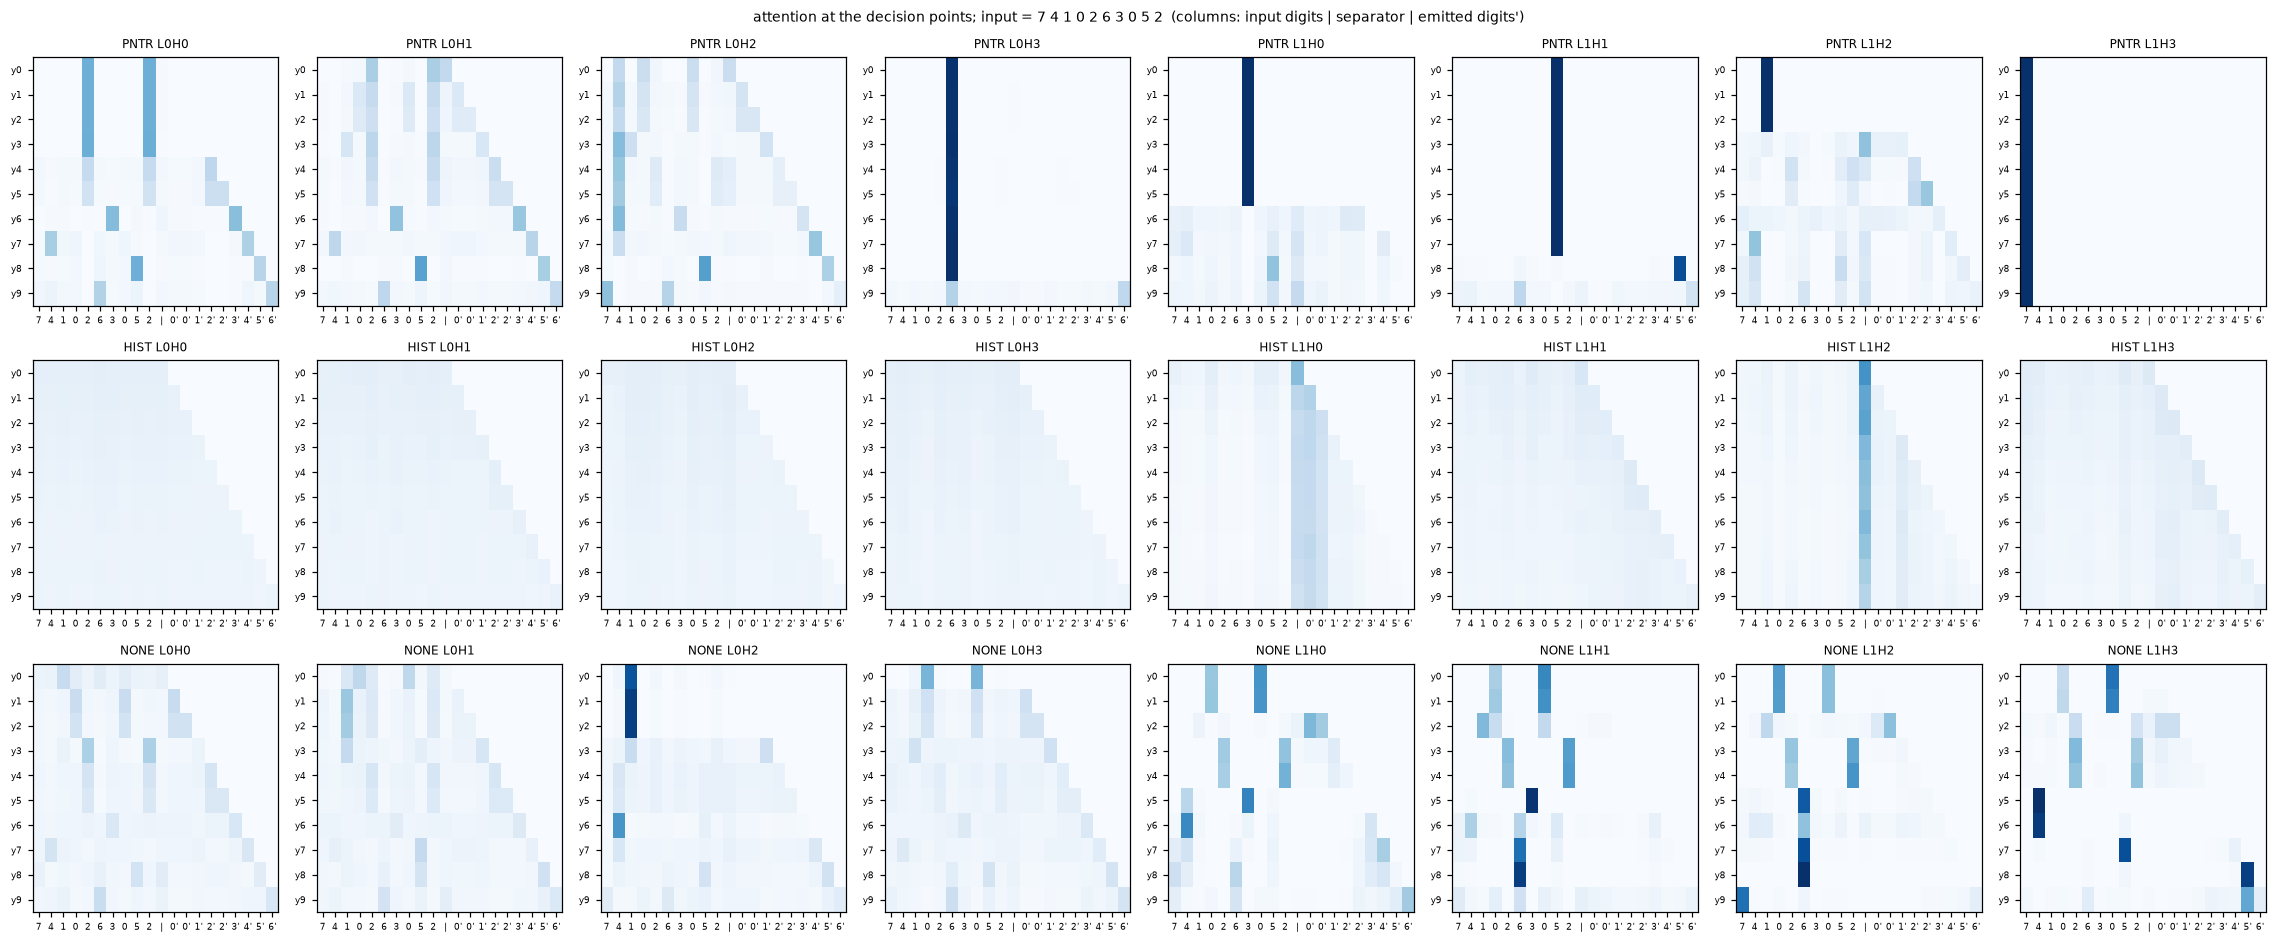

In [ ]:
# Attention patterns of every head, at the n decision points, for one example of length 10.
g = torch.Generator(device=DEVICE).manual_seed(5)
x = sample_inputs(1, 10, device=DEVICE, generator=g)
labels = token_labels(x[0])
fig, axes = plt.subplots(len(models), CFG.n_layers * CFG.n_heads, figsize=(2.6 * CFG.n_layers * CFG.n_heads, 2.9 * len(models)))
for r, (name, m) in enumerate(models.items()):
    attn, y = attention_patterns(m, x)
    for l in range(CFG.n_layers):
        for h in range(CFG.n_heads):
            ax = axes[r, l * CFG.n_heads + h]
            A = attn[l][0, h, 10:, :].cpu().numpy()            # rows: decision points (predict y_0..y_9)
            ax.imshow(A, cmap="Blues", vmin=0, vmax=1, aspect="auto")
            ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=6)
            ax.set_yticks(range(10)); ax.set_yticklabels([f"y{t}" for t in range(10)], fontsize=6)
            ax.set_title(f"{name} L{l}H{h}", fontsize=8); ax.grid(False)
plt.suptitle(f"attention at the decision points; input = {' '.join(map(str, x[0].tolist()))}  (columns: input digits | separator | emitted digits')", fontsize=9)
plt.tight_layout(); plt.savefig("figures/attention.png"); plt.show()

## 9. Geometry: the local learning coefficient

We estimate the LLC of each trained model on a fixed i.i.d. sample of `N` sequences from the training
distribution, with the per-sequence negative log-likelihood as `L_n`, using SGLD as in Lau et al. (2023)
and the diagnostics of the `devinterp` sampling guide (the loss trace must rise above `L_n(w*)`, level off,
agree across chains, and show no spikes or NaNs).

Two practical points, both consequences of how *sharp* these minima are (a loss of ~1e-5 per token means
the logit margins are enormous, and a random perturbation of 0.003 per weight already costs several nats):

* The theoretical inverse temperature `nβ* = N / log N` (≈ 1700 here) makes SGLD diverge for every step
  size we tried, so `nβ` is treated as a sampler knob and swept over `{10, 100}` as the sampling guide
  recommends.  The estimate then scales with `nβ`; only comparisons at *identical* settings are meaningful.
* A strong localisation (`γ = 10⁴`, i.e. a Gaussian ball of radius ~0.01 per weight) and a small step size
  are needed to keep the chains in the region where the loss is still small.  With these settings the
  estimate is a *scale-dependent* count of stiff directions,  λ̂ ≈ ½ Σᵢ nβhᵢ / (nβhᵢ + γ)  in the quadratic
  picture, rather than the asymptotic learning coefficient — but it is the same functional of the local
  geometry for every model, which is what the comparison needs.

The cells below run a small sweep on the `PNTR` model, then use one setting for all models, then an
`nβ = 0` control (no loss-gradient term: the chains only feel the noise and the localisation; if the
estimate does not collapse, the "signal" was never coming from the loss landscape), and finally the
*weight-refined* LLC of Wang et al. (2024) — the same estimate with only one group of parameters free —
to see where each solution's stiffness sits.

In [ ]:
data = FixedDataset(N=4096 if FAST else 16384, n_range=TRAIN["n_range"], seed=2024, device=DEVICE)
print(f"LLC dataset: N={data.N} sequences  (theoretical n*beta* = N/log N = {data.N / math.log(data.N):.0f}, too hot for these minima -- see text)")
for name, m in models.items():
    print(f"{name}: L_n(w*) = {data.full_loss(m, sequence_nll):.6f}   (mean per-sequence NLL on the LLC dataset)")

LLC dataset: N=16380 sequences  (theoretical n*beta* = N/log N = 1688, too hot for these minima -- see text)
PNTR: L_n(w*) = 0.000000   (mean per-sequence NLL on the LLC dataset)


HIST: L_n(w*) = 0.000002   (mean per-sequence NLL on the LLC dataset)
NONE: L_n(w*) = 0.000000   (mean per-sequence NLL on the LLC dataset)


nbeta=   10 eps=1e-05 gamma= 10000: llc=     1.30 +- 0.18 | trace quarters: 0.1187 0.1059 0.1274 0.1333  max=6.778  nan=False


nbeta=   10 eps=1e-05 gamma=  1000: llc=    11.86 +- 0.03 | trace quarters: 0.9350 1.0889 1.3066 1.0652  max=5.104  nan=False


nbeta=  100 eps=1e-06 gamma= 10000: llc=     1.06 +- 0.06 | trace quarters: 0.0107 0.0123 0.0137 0.0075  max=0.245  nan=False


nbeta=  100 eps=1e-06 gamma=  1000: llc=     8.20 +- 0.13 | trace quarters: 0.0333 0.0672 0.0899 0.0740  max=0.703  nan=False


nbeta=  100 eps=1e-05 gamma= 10000: llc=   485.71 +- 104.81 | trace quarters: 4.8733 3.2405 4.1469 5.5673  max=160.007  nan=False


nbeta=   10 eps=1e-04 gamma= 10000: llc=   263.67 +- 10.50 | trace quarters: 26.8668 25.7551 26.0947 26.6395  max=274.131  nan=False


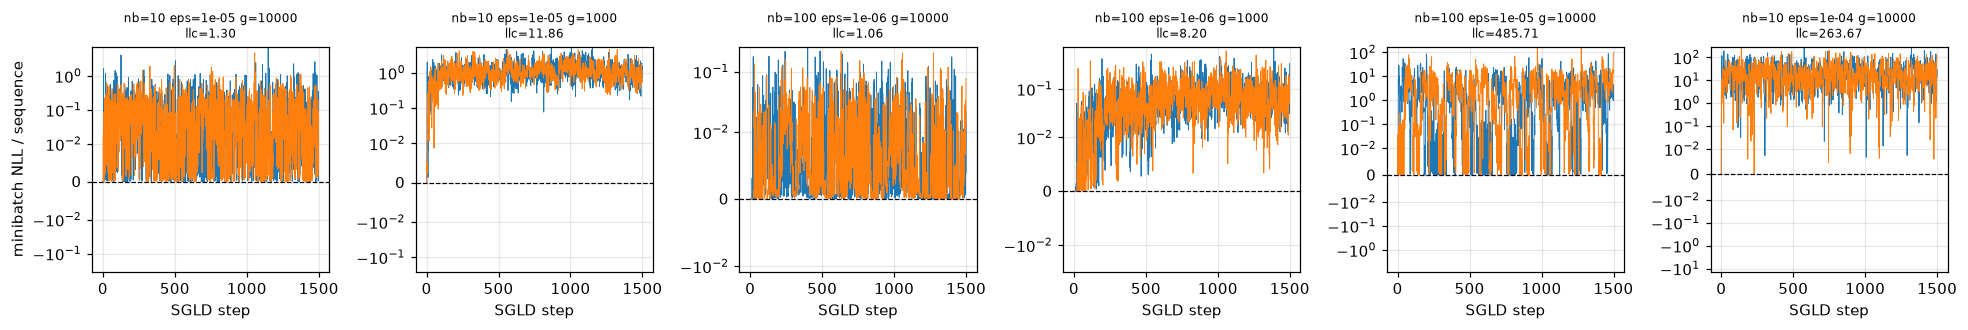

In [ ]:
# Sweep on the PNTR model.  Good traces rise above L(w*), level off, agree across chains, and have no spikes.
SWEEP_STEPS, SWEEP_BURN = (300, 150) if FAST else (1500, 750)
GRID = [(10.0, 1e-5, 1e4), (10.0, 1e-5, 1e3), (100.0, 1e-6, 1e4), (100.0, 1e-6, 1e3), (100.0, 1e-5, 1e4), (10.0, 1e-4, 1e4)] if not FAST else [(10.0, 1e-5, 1e4), (100.0, 1e-6, 1e4)]
sweep = {}
for nbeta, eps, gamma in GRID:
    r = estimate_llc(models["PNTR"], data, eps=eps, gamma=gamma, nbeta=nbeta, n_chains=2, n_steps=SWEEP_STEPS, burnin=SWEEP_BURN, batch=256, seed=1)
    sweep[(nbeta, eps, gamma)] = r
    tr = r["traces"]; q = SWEEP_STEPS // 4
    print(f"nbeta={nbeta:5.0f} eps={eps:.0e} gamma={gamma:6.0f}: llc={r['llc']:9.2f} +- {r['llc_std']:.2f} | trace quarters: {np.nanmean(tr[:, :q]):.4f} {np.nanmean(tr[:, q:2*q]):.4f} {np.nanmean(tr[:, 2*q:3*q]):.4f} {np.nanmean(tr[:, 3*q:]):.4f}  max={np.nanmax(tr):.3f}  nan={np.isnan(tr).any()}")
fig, axes = plt.subplots(1, len(sweep), figsize=(3.0 * len(sweep), 3.1))
for ax, ((nbeta, eps, gamma), r) in zip(np.atleast_1d(axes), sweep.items()):
    for c in range(r["traces"].shape[0]):
        ax.plot(r["traces"][c], lw=0.6)
    ax.axhline(r["L0"], color="k", ls="--", lw=0.8); ax.set_yscale("symlog", linthresh=0.01)
    ax.set_title(f"nb={nbeta:.0f} eps={eps:.0e} g={gamma:.0f}\nllc={r['llc']:.2f}", fontsize=8); ax.set_xlabel("SGLD step")
np.atleast_1d(axes)[0].set_ylabel("minibatch NLL / sequence")
plt.tight_layout(); plt.savefig("figures/llc_sweep.png"); plt.show()

In [ ]:
# Final estimates: identical sampler settings for every model (as recommended when comparing LLCs).
LLC_HP = dict(eps=1e-5, gamma=1e4, nbeta=10.0, batch=256)
LLC_RUN = dict(n_chains=2, n_steps=400, burnin=200) if FAST else dict(n_chains=6, n_steps=2000, burnin=1000)
llc = {}
for name, m in models.items():
    llc[name] = estimate_llc(m, data, seed=7, verbose=True, **LLC_HP, **LLC_RUN)
    print(f"==> {name}: LLC = {llc[name]['llc']:.3f} +- {llc[name]['llc_std']:.3f} (chain std), L_n(w*) = {llc[name]['L0']:.6f}")
# control: nbeta = 0 removes the loss-gradient term (chains only feel noise + localisation)
llc0 = {name: estimate_llc(m, data, seed=7, **{**LLC_HP, "nbeta": 0.0}, **{**LLC_RUN, "n_chains": 2}) for name, m in models.items()}
df_llc = pd.DataFrame({name: {"LLC": r["llc"], "chain std": r["llc_std"], "L_n(w*)": r["L0"], "E[L] - L(w*)": r["llc"] / r["nbeta"],
                              "control nbeta=0: (E[L]-L(w*)) x nbeta": (llc0[name]["traces"][:, LLC_RUN["burnin"]:].mean() - llc0[name]["L0"]) * LLC_HP["nbeta"]}
                       for name, r in llc.items()}).T
df_llc.to_csv("results/llc.csv")
df_llc

  chain 0: L0=0.0000 mean(L)=0.1146 llc=1.15


  chain 1: L0=0.0000 mean(L)=0.1180 llc=1.18


  chain 2: L0=0.0000 mean(L)=0.1108 llc=1.11


  chain 3: L0=0.0000 mean(L)=0.1350 llc=1.35


  chain 4: L0=0.0000 mean(L)=0.1043 llc=1.04


...

  chain 2: L0=0.0000 mean(L)=0.0019 llc=0.02


  chain 3: L0=0.0000 mean(L)=0.0012 llc=0.01


  chain 4: L0=0.0000 mean(L)=0.0013 llc=0.01


  chain 5: L0=0.0000 mean(L)=0.0011 llc=0.01
==> NONE: LLC = 0.015 +- 0.004 (chain std), L_n(w*) = 0.000000


,LLC,chain std,L_n(w*),E[L] - L(w*),control nbeta=0: (E[L]-L(w*)) x nbeta
PNTR,1.177962,0.098169,3.369590e-09,0.117796,34.036428
HIST,0.617451,0.058832,2.315010e-06,0.061745,3.254852
NONE,0.015475,0.003674,1.542879e-09,0.001548,0.039245


In [ ]:
# Robustness: the same comparison at a second sampler setting (colder chains, smaller steps).
LLC_HP2 = dict(eps=1e-6, gamma=1e4, nbeta=100.0, batch=256)
LLC_RUN2 = dict(n_chains=2, n_steps=400, burnin=200) if FAST else dict(n_chains=4, n_steps=2500, burnin=1250)
llc2 = {name: estimate_llc(m, data, seed=9, **LLC_HP2, **LLC_RUN2) for name, m in models.items()}
df_llc2 = pd.DataFrame({name: {"LLC (setting 2)": r["llc"], "chain std": r["llc_std"], "trace mean after burn-in": r["traces"][:, LLC_RUN2["burnin"]:].mean(), "L_n(w*)": r["L0"]}
                        for name, r in llc2.items()}).T
df_llc2.to_csv("results/llc_setting2.csv")
df_llc2

,LLC (setting 2),chain std,trace mean after burn-in,L_n(w*)
PNTR,1.107367,0.031683,0.011074,3.369590e-09
HIST,1.180645,0.161933,0.011809,2.315010e-06
NONE,0.051276,0.017102,0.000513,1.542879e-09


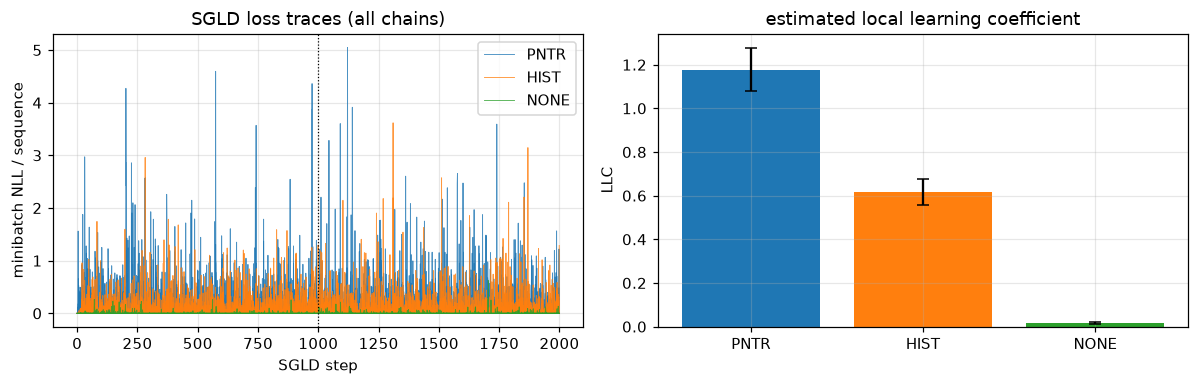

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for name, r in llc.items():
    for c in range(r["traces"].shape[0]):
        axes[0].plot(r["traces"][c], lw=0.6, color={"PNTR": "C0", "HIST": "C1", "NONE": "C2"}[name], alpha=0.8, label=name if c == 0 else None)
axes[0].axvline(LLC_RUN["burnin"], color="k", ls=":", lw=0.8); axes[0].set_xlabel("SGLD step"); axes[0].set_ylabel("minibatch NLL / sequence"); axes[0].set_title("SGLD loss traces (all chains)"); axes[0].legend()
names = list(llc); vals = [llc[k]["llc"] for k in names]; errs = [llc[k]["llc_std"] for k in names]
axes[1].bar(names, vals, yerr=errs, capsize=4, color=["C0", "C1", "C2"][:len(names)]); axes[1].set_title("estimated local learning coefficient"); axes[1].set_ylabel("LLC")
plt.tight_layout(); plt.savefig("figures/llc.png"); plt.show()

PNTR  embeddings         (   2688 params): rLLC =     0.00 +- 0.00


PNTR  attention          ( 132096 params): rLLC =     0.84 +- 0.06


PNTR  MLPs               ( 263424 params): rLLC =     0.00 +- 0.00


PNTR  state + read-out   (   6997 params): rLLC =     0.18 +- 0.04


HIST  embeddings         (   2688 params): rLLC =     0.00 +- 0.00


...

HIST  state + read-out   (   6997 params): rLLC =     0.16 +- 0.02


NONE  embeddings         (   2688 params): rLLC =     0.00 +- 0.00


NONE  attention          ( 132096 params): rLLC =     0.02 +- 0.01


NONE  MLPs               ( 263424 params): rLLC =     0.00 +- 0.00


NONE  state + read-out   (   6997 params): rLLC =     0.00 +- 0.00


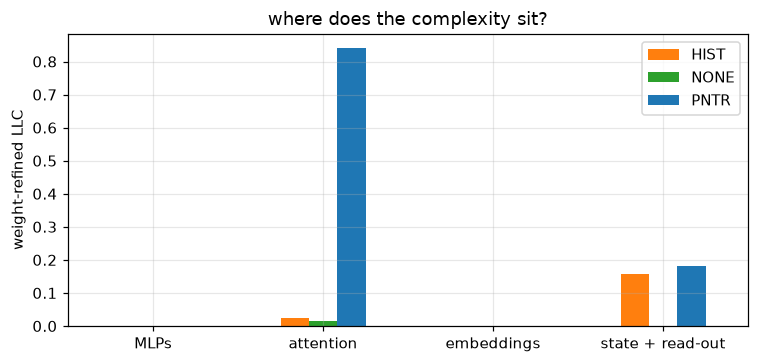

In [ ]:
# Weight-refined LLC (Wang et al. 2024): sample only one group of parameters at a time, everything else
# frozen at w*.  Same sampler settings as above.  This asks *where* each solution's complexity sits.
GROUPS = {"embeddings": lambda n: "emb" in n,
          "attention": lambda n: ".attn." in n,
          "MLPs": lambda n: ".mlp." in n,
          "state + read-out": lambda n: n.startswith("state") or n.startswith("readout")}
RLLC_RUN = dict(n_chains=2, n_steps=300, burnin=150) if FAST else dict(n_chains=4, n_steps=1200, burnin=600)
rllc = {}
for name, m in models.items():
    for gname, filt in GROUPS.items():
        r = estimate_llc(m, data, seed=11, param_filter=filt, **LLC_HP, **RLLC_RUN)
        rllc[(name, gname)] = {"rLLC": r["llc"], "chain std": r["llc_std"], "#params": r["n_params"]}
        print(f"{name:5s} {gname:18s} ({r['n_params']:7d} params): rLLC = {r['llc']:8.2f} +- {r['llc_std']:.2f}")
df_rllc = pd.DataFrame(rllc).T; df_rllc.to_csv("results/refined_llc.csv")
fig, ax = plt.subplots(figsize=(7, 3.4))
piv = df_rllc["rLLC"].unstack(0)
piv.plot.bar(ax=ax, color=[{"PNTR": "C0", "HIST": "C1", "NONE": "C2"}[c] for c in piv.columns], rot=0)
ax.set_ylabel("weight-refined LLC"); ax.set_title("where does the complexity sit?")
plt.tight_layout(); plt.savefig("figures/refined_llc.png"); plt.show()

### 9b. Seeds

One model per algorithm is an anecdote.  Here we train two more of each (different seeds, otherwise
identical) and repeat the length-generalisation, prefix-corruption and LLC measurements, so that the
claims in the discussion rest on three models per algorithm.

In [ ]:
# Seeds: train two more models of each kind (different initialisation and data stream, everything else
# identical) and repeat the length-generalisation, prefix and LLC measurements.
SEEDS = [1] if FAST else [1, 2]
seed_models = {}
for seed in SEEDS:
    for name, mode in MODES.items():
        print(f"===== training {name} seed {seed} =====")
        seed_models[(name, seed)] = train_model(mode, CFG, device=DEVICE, verbose=False, **{**TRAIN, "seed": seed})[0]
all_models = {**{(name, TRAIN["seed"]): m for name, m in models.items()}, **seed_models}
seed_rows, seed_ood = [], {}
for (name, seed), m in all_models.items():
    r_llc = llc[name] if seed == TRAIN["seed"] else estimate_llc(m, data, seed=7, **LLC_HP, **{**LLC_RUN, "n_chains": 4})
    oo = ood[name] if seed == TRAIN["seed"] else evaluate_lengths(m, OOD_LENGTHS, B=1024, device=DEVICE)
    pp = ps[name] if seed == TRAIN["seed"] else prefix_sensitivity(m, n=10, B=2048, device=DEVICE)
    seed_ood[(name, seed)] = oo
    seed_rows.append({"model": name, "seed": seed, "L_n(w*)": r_llc["L0"], "LLC": r_llc["llc"], "LLC chain std": r_llc["llc_std"],
                      **{f"exact@n={n}": next(x["exact"] for x in oo if x["n"] == n) for n in [10, 12, 14, 16, 20, 24, 32]},
                      "follows prefix": pp["follows_prefix(PNTR-like)"], "ignores prefix": pp["ignores_prefix(HIST-like)"]})
    print(f"{name:5s} seed {seed}: LLC = {r_llc['llc']:.3f} +- {r_llc['llc_std']:.3f}  exact@20 = {seed_rows[-1]['exact@n=20']:.3f}")
df_seeds = pd.DataFrame(seed_rows).set_index(["model", "seed"]).sort_index(); df_seeds.to_csv("results/seeds.csv")
df_seeds

===== training PNTR seed 1 =====


===== training HIST seed 1 =====


===== training NONE seed 1 =====


===== training PNTR seed 2 =====


===== training HIST seed 2 =====


...

NONE  seed 1: LLC = 0.037 +- 0.005  exact@20 = 0.892


PNTR  seed 2: LLC = 0.912 +- 0.057  exact@20 = 0.876


HIST  seed 2: LLC = 0.606 +- 0.018  exact@20 = 0.000


NONE  seed 2: LLC = 0.046 +- 0.026  exact@20 = 0.901


L_n(w*)       LLC  LLC chain std  exact@n=10  exact@n=12  \
model seed                                                                  
HIST  0     2.315010e-06  0.617451       0.058832         1.0    0.999023   
      1     2.729751e-06  0.621487       0.070600         1.0    0.999023   
      2     1.790553e-06  0.605989       0.018329         1.0    0.996094   
NONE  0     1.542879e-09  0.015475       0.003674         1.0    1.000000   
      1     2.721432e-06  0.036505       0.004509         1.0    1.000000   
      2     5.474787e-06  0.045880       0.026411         1.0    1.000000   
PNTR  0     3.369590e-09  1.177962       0.098169         1.0    1.000000   
      1     1.100391e-08  1.221716       0.039016         1.0    1.000000   
      2     8.696891e-09  0.911814       0.056708         1.0    1.000000   

            exact@n=14  exact@n=16  exact@n=20  exact@n=24  exact@n=32  \
model seed                                                               
HIST  0       0.702148    0.034180    0.000000    0.000000    0.000000   
      1       0.349609    0.001953    0.000000    0.000000    0.000000   
      2       0.703125    0.003906    0.000000    0.000000    0.000000   
NONE  0       1.000000    0.997070    0.831055    0.311523    0.001953   
      1       1.000000    0.999023    0.891602    0.158203    0.000977   
      2       1.000000    0.999023    0.901367    0.426758    0.000000   
PNTR  0       1.000000    0.998047    0.982422    0.868164    0.266602   
      1       0.999023    0.994141    0.928711    0.747070    0.168945   
      2       0.997070    0.988281    0.875977    0.669922    0.232422   

            follows prefix  ignores prefix  
model seed                                  
HIST  0           0.012069        0.831034  
      1           0.000000        0.883333  
      2           0.014943        0.770115  
NONE  0           0.720690        0.211494  
      1           0.732184        0.186782  
      2           0.735632        0.186782  
PNTR  0           0.994828        0.004598  
      1           1.000000        0.000000  
      2           0.967241        0.013793

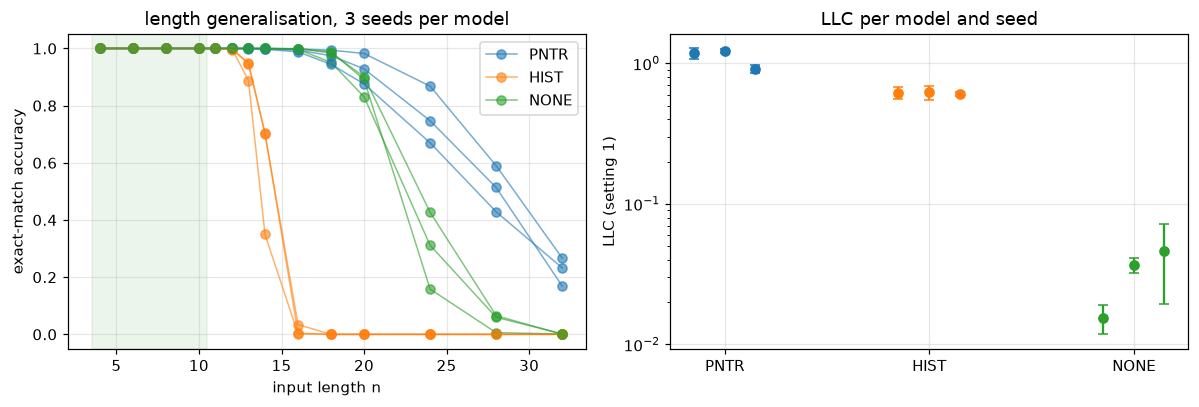

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
colors = {"PNTR": "C0", "HIST": "C1", "NONE": "C2"}
for (name, seed), oo in seed_ood.items():
    axes[0].plot([r["n"] for r in oo], [r["exact"] for r in oo], "o-", color=colors[name], alpha=0.6, lw=1, label=name if seed == TRAIN["seed"] else None)
axes[0].axvspan(TRAIN["n_range"][0] - 0.5, TRAIN["n_range"][1] + 0.5, color="green", alpha=0.08)
axes[0].set_xlabel("input length n"); axes[0].set_ylabel("exact-match accuracy"); axes[0].set_title(f"length generalisation, {1 + len(SEEDS)} seeds per model"); axes[0].legend()
for i, name in enumerate(MODES):
    sub = df_seeds.loc[name]
    axes[1].errorbar([i + 0.15 * (k - 1) for k in range(len(sub))], sub["LLC"], yerr=sub["LLC chain std"], fmt="o", color=colors[name], capsize=3)
axes[1].set_xticks(range(len(MODES))); axes[1].set_xticklabels(list(MODES)); axes[1].set_ylabel("LLC (setting 1)"); axes[1].set_title("LLC per model and seed"); axes[1].set_yscale("log")
plt.tight_layout(); plt.savefig("figures/seeds.png"); plt.show()

## 10. Ablations

**A. Position embeddings.**  The main run uses *no* position embeddings, so the only thing that
changes out of distribution is the number of tokens.  Here the same two models are trained with learned
absolute position embeddings (zero-initialised, so unseen positions contribute nothing).

**B. Is the bottleneck necessary?**  The naive way to "supervise a state" is to add a linear probe on the
residual stream and train it jointly with the sorting loss.  Without the bottleneck the read-out can use
the whole residual stream, and the probe only has to be *satisfiable*, not *used*.

In [ ]:
# Ablation A: learned absolute position embeddings (zero-initialised) instead of no position embeddings.
CFG_PE = Config(**{**CFG.__dict__, "pos": "learned"})
models_pe = {}
for name, mode in [("PNTR", "pntr"), ("HIST", "hist")]:
    print(f"===== training {name} with learned position embeddings =====")
    models_pe[name], _ = train_model(mode, CFG_PE, device=DEVICE, verbose=False, **TRAIN)
ood_pe = {name: evaluate_lengths(m, OOD_LENGTHS, B=1024, device=DEVICE) for name, m in models_pe.items()}
ps_pe = {name: prefix_sensitivity(m, n=10, B=2048, device=DEVICE) for name, m in models_pe.items()}
fid_pe = {name: state_fidelity(m, n_range=TRAIN["n_range"], device=DEVICE) for name, m in models_pe.items()}
print(pd.DataFrame(ps_pe).T); print(pd.DataFrame(fid_pe).T)

===== training PNTR with learned position embeddings =====


===== training HIST with learned position embeddings =====


      follows_prefix(PNTR-like)  ignores_prefix(HIST-like)     other  n_cases
PNTR                   0.999425                   0.000575  0.000000   1740.0
HIST                   0.014368                   0.818391  0.167241   1740.0
      mse_vs_PNTR_state  avail_bit_acc  mse_vs_HIST_state  count_acc
PNTR           0.008641       1.000000          16.961625   0.101993
HIST          19.010930       0.395376           0.098865   0.872161


In [ ]:
# Ablation B: no bottleneck -- the naive version of supervised-state training.  The sorting head reads the
# whole residual stream and the algorithm's state is only *encouraged* by a jointly trained linear probe.
CFG_NB = Config(**{**CFG.__dict__, "bottleneck": False})
models_nb = {}
for name, mode in [("PNTR", "pntr"), ("HIST", "hist")]:
    print(f"===== training {name} without the bottleneck (joint probe loss) =====")
    models_nb[name], _ = train_model_joint(mode, CFG_NB, steps=TRAIN["steps"], batch=TRAIN["batch"], lr=TRAIN["lr"],
                                           n_range=TRAIN["n_range"], seed=TRAIN["seed"], device=DEVICE, verbose=False)
ood_nb = {name: evaluate_lengths(m, OOD_LENGTHS, B=1024, device=DEVICE) for name, m in models_nb.items()}
ps_nb = {name: prefix_sensitivity(m, n=10, B=2048, device=DEVICE) for name, m in models_nb.items()}
probes_nb = {name: probe_report(m, which="final", device=DEVICE) for name, m in models_nb.items()}
print(pd.DataFrame(ps_nb).T); print(pd.DataFrame(probes_nb).T)

===== training PNTR without the bottleneck (joint probe loss) =====


===== training HIST without the bottleneck (joint probe loss) =====


      follows_prefix(PNTR-like)  ignores_prefix(HIST-like)     other  n_cases
PNTR                   0.705172                   0.258621  0.036207   1740.0
HIST                   0.591954                   0.333333  0.074713   1740.0
       hist_R2  hist_count_acc    idx_R2  avail_bit_acc
PNTR  0.835629        0.876718  0.887209       0.999817
HIST  0.936389        0.973139  0.993721       0.982242


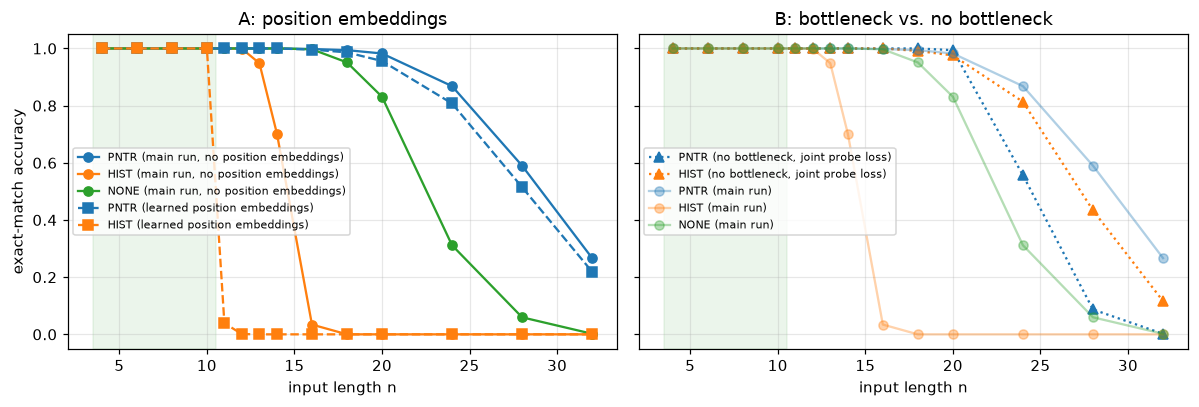

exact@n=10  exact@n=12  exact@n=16  exact@n=20  \
variant       model                                                   
no PE (main)  PNTR          1.0    1.000000    0.998047    0.982422   
              HIST          1.0    0.999023    0.034180    0.000000   
              NONE          1.0    1.000000    0.997070    0.831055   
learned PE    PNTR          1.0    1.000000    0.996094    0.956055   
              HIST          1.0    0.000977    0.000000    0.000000   
no bottleneck PNTR          1.0    1.000000    1.000000    0.994141   
              HIST          1.0    1.000000    1.000000    0.975586   

                     exact@n=24  exact@n=32  follows_prefix(PNTR-like)  \
variant       model                                                      
no PE (main)  PNTR     0.868164    0.266602                   0.994828   
              HIST     0.000000    0.000000                   0.012069   
              NONE     0.311523    0.001953                   0.720690   
learned PE    PNTR     0.807617    0.218750                   0.999425   
              HIST     0.000000    0.000000                   0.014368   
no bottleneck PNTR     0.556641    0.001953                   0.705172   
              HIST     0.813477    0.116211                   0.591954   

                     ignores_prefix(HIST-like)     other  n_cases  
variant       model                                                
no PE (main)  PNTR                    0.004598  0.000575     1740  
              HIST                    0.831034  0.156897     1740  
              NONE                    0.211494  0.067816     1740  
learned PE    PNTR                    0.000575  0.000000     1740  
              HIST                    0.818391  0.167241     1740  
no bottleneck PNTR                    0.258621  0.036207     1740  
              HIST                    0.333333  0.074713     1740

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for name, rs in ood.items():
    axes[0].plot([r["n"] for r in rs], [r["exact"] for r in rs], "o-", color={"PNTR": "C0", "HIST": "C1", "NONE": "C2"}[name], label=f"{name} (main run, no position embeddings)")
for name, rs in ood_pe.items():
    axes[0].plot([r["n"] for r in rs], [r["exact"] for r in rs], "s--", color={"PNTR": "C0", "HIST": "C1"}[name], label=f"{name} (learned position embeddings)")
for name, rs in ood_nb.items():
    axes[1].plot([r["n"] for r in rs], [r["exact"] for r in rs], "^:", color={"PNTR": "C0", "HIST": "C1"}[name], label=f"{name} (no bottleneck, joint probe loss)")
for name, rs in ood.items():
    axes[1].plot([r["n"] for r in rs], [r["exact"] for r in rs], "o-", color={"PNTR": "C0", "HIST": "C1", "NONE": "C2"}[name], alpha=0.35, label=f"{name} (main run)")
for ax, t in zip(axes, ["A: position embeddings", "B: bottleneck vs. no bottleneck"]):
    ax.axvspan(TRAIN["n_range"][0] - 0.5, TRAIN["n_range"][1] + 0.5, color="green", alpha=0.08)
    ax.set_xlabel("input length n"); ax.set_title(t); ax.legend(fontsize=7)
axes[0].set_ylabel("exact-match accuracy")
plt.tight_layout(); plt.savefig("figures/ablations.png"); plt.show()
rows = []
for tag, oo, pp in [("no PE (main)", ood, ps), ("learned PE", ood_pe, ps_pe), ("no bottleneck", ood_nb, ps_nb)]:
    for name in pp:
        r = {"variant": tag, "model": name, **{f"exact@n={n}": next(x["exact"] for x in oo[name] if x["n"] == n) for n in [10, 12, 16, 20, 24, 32]}, **pp[name]}
        rows.append(r)
df_abl = pd.DataFrame(rows).set_index(["variant", "model"]); df_abl.to_csv("results/ablations.csv")
df_abl

## 11. Discussion

**What the toy shows.**

1. *Underspecification is real even for a 400k-parameter sorter.*  `PNTR` and `HIST` have the same
   architecture, saw the same data stream, and end at a sorting loss that is zero to within noise
   (about 1e-9 and 3e-7 nats per token) with 100% exact-match accuracy on the training distribution
   (Section 5).  The moment the inputs get longer they diverge: `PNTR` still sorts every 16-digit string and
   87% of 24-digit strings, `HIST` is at 3% by n = 16 and 0% from n = 18 on (Section 6).  No evaluation
   on the training distribution would have told them apart — the situation *You Are What You Eat*
   calls the underspecification problem and Hoogland's essay the generalisation problem.
2. *The difference is algorithmic.*  With a plausible-but-wrong prefix, `PNTR` follows the prefix 99%
   of the time and never ignores it; `HIST` follows it 1% of the time and ignores it 83% of the time
   (Section 8).  Each bottleneck holds its own algorithm's state and not the other's (Section 4).  The
   attention maps show it directly: `PNTR`'s heads do sharp content look-ups of particular input digits,
   `HIST`'s layer-0 heads attend uniformly over the inputs (that *is* the histogram) and its layer-1 heads
   read the separator (under no position embeddings, the fraction of attention that lands on the
   separator is how the model knows n and t).
3. *Which algorithm fails, and why, follows from what its state has to represent.*  The pointer-tracker's
   state is made of comparisons ("is digit d still available?"), the same computation at any length.  The
   counting sorter's state is made of absolute magnitudes — counts and an output index — whose training
   range is bounded, so every implementation has to extrapolate them.  Position embeddings only move the
   cliff (ablation A): with none, the counter fails a few positions past the training range (it has to
   extrapolate a fraction→count map); with learned ones it fails immediately (4% at n = 11).  The
   duplicates control (Section 7) makes the same point from the other side: at n = 10 the counter is fine
   until the histogram itself becomes unlike anything seen in training (all ten digits equal: 0% exact).
4. *Supervising a state does not by itself change the algorithm.*  Without the bottleneck (ablation B)
   the auxiliary probe is satisfied — the histogram is linearly decodable from the `HIST`-probed model
   with R² ≈ 0.94 — while the model goes on sorting by tracking the minimum (59% follows-prefix, full
   length generalisation).  Representation is not use; a probe finding a variable is not evidence that the
   variable is on the computational path.
5. *SGD's default is the pointer-tracker.*  The unsupervised `NONE` model behaves like `PNTR` in every test
   (72% follows-prefix, generalises to n = 20 at 83%), and its attention maps look like `PNTR`'s.  Counting
   sort is the algorithm that had to be scaffolded in.

**What the LLC says.**  With one sampler setting for all models (nβ = 10, γ = 10⁴, ε = 10⁻⁵; chains agree
to within ~10%, and the nβ = 0 control collapses to ~0), three seeds per model (Section 9b), and a colder
second setting (nβ = 100, ε = 10⁻⁶) as a check:

* `NONE` is *far* more degenerate than either scaffolded solution — λ̂ ≈ 0.015–0.05 against ≈ 0.9–1.2
  (`PNTR`) and ≈ 0.6 (`HIST`) at the first setting, and ≈ 0.05 against ≈ 1.1–1.2 at the second; this holds
  for every seed and both settings.  Whatever SGD finds on its own sits in a much flatter region than what
  supervised-state training produces, even though its algorithm is `PNTR`'s.  (Part of this is procedure:
  `NONE` spent all of training being annealed by SGD on the sorting loss, `PNTR`/`HIST` only the last 20% at
  a small learning rate; SGD's implicit drift towards flat regions is itself one of the phenomena the LLC
  was introduced to measure — Lau et al.'s Figure 1.)
* Between the two solutions with equal loss the picture is *scale-dependent*.  At the first setting the
  LLC separates them by a factor of two, consistently across seeds (`PNTR` 1.18, 1.22, 0.91 vs `HIST` 0.62,
  0.62, 0.61, chain spreads ≈ 0.02–0.10), and the weight-refined LLC says where: `PNTR`'s stiffness is in its
  **attention** weights (rLLC ≈ 0.8 of the total 1.2 — sharp content look-ups are fragile), `HIST`'s
  attention is almost free (≈ 0.03 — uniform averaging is robust) and its stiffness sits in the
  **state/read-out** thresholds (≈ 0.16).  At the colder setting, which counts directions of lower
  curvature as well, the two are indistinguishable (1.11 ± 0.03 vs 1.18 ± 0.16).  So geometry does
  separate the two equal-loss solutions, but the separation is a statement about their *stiffest few
  directions*, not about the volume of their basins at every scale.
* And where it separates them, the *direction* is the opposite of "simpler generalises better": at the
  first setting the brittle counting sorter is the more degenerate of the two.  Read through Eq. (3) of
  *You Are What You Eat*, nΔℓ ≈ 16380 × 2.3·10⁻⁶ ≈ 0.04 nats is negligible next to Δλ·log n ≈ 0.6 × 9.7 ≈ 5
  nats, so a posterior at that temperature would prefer `HIST` to `PNTR` by roughly e⁵ (and `NONE` to both by
  far more); at the second setting the odds between `PNTR` and `HIST` are even.  The honest summary is that
  the LLC ranks *implementations* at a chosen scale, and neither the ranking of the two scaffolded
  implementations nor its sign is something one should read a generalisation guarantee from.

**Relation to the safety argument.**  The alignment version of this story replaces "sort longer strings"
by "behave well off the training distribution" and "which solution SGD finds" by "which solution the
posterior prefers".  The toy reproduces the premise (equal loss, different algorithms, divergence under
shift) and shows the geometric tool doing what it is supposed to do (distinguishing the solutions in
distribution, and localising where they differ), while also showing the caveat that matters for safety:
the lower-λ solution is not automatically the one that generalises the way you want.  The "S4"
programme — learn which *data* produces which *geometry* produces which *algorithm* — is exactly the map
one would need to predict, before the shift, which of these two a given training set will yield.

**Limitations and next steps.**  (i) The scaffold is strong (an explicit bottleneck plus a teacher-forced
read-out); weaker elicitation — attention supervision, or data engineering alone — would be closer to
how real training shapes algorithms.  (ii) Three seeds per model (Section 9b) is enough to see that the
orderings are stable across seeds, not to estimate their distribution.  (iii) The LLC is estimated at two
localisation scales chosen by the standard diagnostics; because the minima are extremely sharp, the
estimate is a scale-dependent count of stiff directions rather than the asymptotic learning coefficient,
and — as the two settings show — conclusions about *which* of two solutions is simpler can change with the
scale.  Data-refined LLCs (e.g. restricted to long sequences) and susceptibilities would be the natural
next tools.  (iv) The natural developmental question — does the counting sorter's body→read-out hand-off
show up as a phase transition in λ̂(t) over training? — is a small extension of this notebook.

In [ ]:
summary = {"train": train_stats, "ood_length": {k: v for k, v in ood.items()}, "prefix_sensitivity": ps,
           "probes": {f"{k[0]}/{k[1]}": v for k, v in probe_rows.items()},
           "llc": {k: {kk: vv for kk, vv in v.items() if kk != "traces"} for k, v in llc.items()},
           "llc_setting2": {k: {kk: vv for kk, vv in v.items() if kk != "traces"} for k, v in llc2.items()},
           "seeds": seed_rows,
           "state_fidelity": fid, "ood_duplicates": dup_rows, "refined_llc": {f"{k[0]}/{k[1]}": v for k, v in rllc.items()}, "ablation_pe": {"ood": ood_pe, "prefix": ps_pe, "fidelity": fid_pe},
           "ablation_no_bottleneck": {"ood": ood_nb, "prefix": ps_nb, "probes": probes_nb},
           "config": CFG.__dict__, "train_hp": TRAIN, "llc_hp": LLC_HP, "llc_run": LLC_RUN, "device": DEVICE}
json.dump(summary, open("results/summary.json", "w"), indent=1, default=float)
for name, m in models.items():
    torch.save({"cfg": CFG.__dict__, "state": m.state_dict()}, f"results/model_{name}.pt")
print("saved results/summary.json and model checkpoints")

saved results/summary.json and model checkpoints


## 12. Reproduction

* Everything in this notebook is self-contained; `slt_sorting_lib.py` in the repository is the same
  code.  `SLT_FAST=1 jupyter nbconvert --execute slt_sorting.ipynb` runs a reduced version on CPU in a
  few minutes; the full run takes well under an hour on a single small GPU.
* The committed outputs were produced on a rented GPU through Hugging Face Jobs with
  `python run_on_hf_jobs.py launch --notebook slt_sorting.ipynb --flavor t4-small`; the script uploads
  the notebook to a private dataset repo, runs it with `papermill`, and brings back the executed
  notebook, figures and `results/`.